# Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from google.colab import files

from scipy.cluster.hierarchy import dendrogram

import seaborn as sns

from sklearn.cluster import (
  AgglomerativeClustering,
  KMeans,
)
from sklearn.decomposition import PCA
from sklearn.metrics import (
  calinski_harabasz_score,
  silhouette_samples,
  silhouette_score,
)
from sklearn.metrics.cluster import (
  adjusted_rand_score,
  rand_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset

In [ ]:
# Read main table
df = pd.read_csv("/content/main table final.csv")
pd.set_option('display.max_columns', None)
df

,order_id,order_item_id,customer_id,seller_id,product_id,order_ts,order_date,order_week,order_month,order_hour,weekday_num,weekday_name,quantity,order_approved_at,shipping_limit_date,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,revenue,customer_city,customer_state,seller_city,seller_state,order_sequence,cohort_month,customer_type
0,f1dc649e1ea6789e7eddbdaf40aaddb1,1,00d447911e5d5ae87480df8734b915f2,c864036feaab8c1659f65ea4faebe1da,55552e80f046fafe13e130e6a07745e2,2018-08-01 20:21:24.000,2018-08-01,2018-07-30 00:00:00.000,2018-08-01 00:00:00.000,20,3,Wed,1,2018-08-03 04:35:15.000,2018-08-07 04:35:15.000,2018-08-03 12:49:00.000,2018-08-09 20:18:45.000,2018-08-28 00:00:00.000,219.90,60.75,280.65,niteroi,RJ,campo largo,PR,1,2018-08-01 00:00:00.000,New
1,d95b2210692db91db720c1ef8b02c1cd,1,00d474cea9ceb88b7175d564b081dfa3,69a43819c758c65a5befb0b471c954d7,9867ef342d95bb4f9b6ebf39bad864f7,2017-06-15 11:48:29.000,2017-06-15,2017-06-12 00:00:00.000,2017-06-01 00:00:00.000,11,4,Thu,1,2017-06-15 12:03:08.000,2017-06-21 12:03:08.000,2017-06-16 17:22:10.000,2017-06-23 12:32:23.000,2017-07-20 00:00:00.000,99.95,15.45,115.40,imbituba,SC,apucarana,PR,1,2017-06-01 00:00:00.000,New
2,fd6ae3b1149c4a3a920086befc628e3d,1,00d4ef3e086e2191c3fb6e7b0d2a1c75,aafe36600ce604f205b86b5084d3d767,57e089e3103f5cda6a4ce23b77399bdb,2018-06-30 12:19:32.000,2018-06-30,2018-06-25 00:00:00.000,2018-06-01 00:00:00.000,12,6,Sat,1,2018-07-05 16:26:52.000,2018-07-05 04:31:45.000,2018-07-04 12:02:00.000,2018-07-10 23:19:36.000,2018-07-27 00:00:00.000,47.90,19.53,67.43,bauru,SP,sao jose,SC,1,2018-06-01 00:00:00.000,New
3,e7ce593c46f447cf67788cfb73581ad7,1,00d76f8bb8df7e07711da4076c52ffe0,951e8cef368f09bb3f3d03c00ca4702c,45f4784fe1b64e1e5a1b9dade6a83e88,2018-07-14 12:22:31.000,2018-07-14,2018-07-09 00:00:00.000,2018-07-01 00:00:00.000,12,6,Sat,1,2018-07-17 04:32:00.000,2018-07-23 04:32:00.000,2018-07-17 13:53:00.000,2018-07-20 16:41:36.000,2018-08-01 00:00:00.000,105.99,18.84,124.83,ribeirao das neves,MG,ibitinga,SP,1,2018-07-01 00:00:00.000,New
4,1657d073874b59831bbf61d290efb44a,1,00d7812c158831a996a6b3f4698643b5,9f505651f4a6abe901a56cdc21508025,d33a74e1b6cfc152b6b3f43324d54987,2018-08-19 18:12:07.000,2018-08-19,2018-08-13 00:00:00.000,2018-08-01 00:00:00.000,18,7,Sun,1,2018-08-20 13:40:15.000,2018-08-22 12:50:18.000,2018-08-20 16:07:00.000,2018-08-21 22:45:36.000,2018-08-28 00:00:00.000,14.99,8.29,23.28,jundiai,SP,sao paulo,SP,1,2018-08-01 00:00:00.000,New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110192,fc0c50f90120412d596dbda411f6fbe4,1,00d012266be1430eec790d0f405a836c,128639473a139ac0f3e5f5ade55873a5,82e4ad16521ca131d95e198d507db370,2018-04-19 13:15:35.000,2018-04-19,2018-04-16 00:00:00.000,2018-04-01 00:00:00.000,13,4,Thu,1,2018-04-19 14:30:50.000,2018-04-25 13:33:15.000,2018-04-19 23:48:32.000,2018-04-26 22:29:33.000,2018-05-15 00:00:00.000,18.90,18.23,37.13,porto alegre,RS,maringa,PR,1,2018-04-01 00:00:00.000,New
110193,7d1ac7d65c6b5d59a9ac241fa41da57d,1,00d03b5e33f8987549c5590313a4ef21,b76dba6c951ab00dc4edf0a1aa88037e,4633dfeb3a2588bdb52af32d504b44eb,2017-06-16 23:17:41.000,2017-06-16,2017-06-12 00:00:00.000,2017-06-01 00:00:00.000,23,5,Fri,1,2017-06-16 23:30:10.000,2017-07-05 23:30:10.000,2017-06-19 11:15:51.000,2017-06-29 11:06:37.000,2017-08-02 00:00:00.000,19.99,15.10,35.09,pantano grande,RS,sao paulo,SP,1,2017-06-01 00:00:00.000,New
110194,678f4895096d4e79441a761f3d6c6b29,1,00d079bd851bf5d13879d7a2a3b5ec48,c826c40d7b19f62a09e2d7c5e7295ee2,3b60d513e90300a4e9833e5cda1f1d61,2018-01-19 11:41:03.000,2018-01-19,2018-01-15 00:00:00.000,2018-01-01 00:00:00.000,11,5,Fri,1,2018-01-19 11:54:30.000,2018-01-25 11:54:30.000,2018-01-22 18:39:01.000,2018-02-09 01:21:39.000,2018-02-22 00:00:00.000,159.77,18.69,178.46,tangara da serra,MT,guarulhos,SP,1,2018-01-01 00:00:00.000,New
110195,9988bc711d2d6fead4af40481ff5de63,1,00d1e5d82377766dac9f

In [ ]:
# Read dataset category product
df_category= pd.read_csv('/content/product_category_name_translation.csv')
df_category

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [ ]:
# Load dataset products
df_product = pd.read_csv('/content/olist_products_dataset.csv')
df_product

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [ ]:
# Merge products dataset with df
df = df.merge(
    df_product[['product_id', 'product_category_name', 'product_description_lenght', 'product_photos_qty', 'product_weight_g' ]],
    on='product_id',
    how='left'
)

In [ ]:
# Merge category dataset with df
df = df.merge(
    df_category[['product_category_name', 'product_category_name_english']],
    on='product_category_name',
    how='left'
)

#  Data Cleaning

In [ ]:
# Dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       110197 non-null  object 
 1   order_item_id                  110197 non-null  int64  
 2   customer_id                    110197 non-null  object 
 3   seller_id                      110197 non-null  object 
 4   product_id                     110197 non-null  object 
 5   order_ts                       110197 non-null  object 
 6   order_date                     110197 non-null  object 
 7   order_week                     110197 non-null  object 
 8   order_month                    110197 non-null  object 
 9   order_hour                     110197 non-null  int64  
 10  weekday_num                    110197 non-null  int64  
 11  weekday_name                   110197 non-null  object 
 12  quantity                      

In [ ]:
# Row and column dataset
df.shape

(110197, 33)

## Data type

In [ ]:
# Handle incorrect data types by converting columns to appropriate formats
# Date and datetime
datetime_cols = [
    'order_ts',
    'order_approved_at',
    'shipping_limit_date',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['order_date'] = df['order_ts'].dt.date

# week, month, and cohort
df['order_week'] = df['order_ts'].dt.to_period('W')
df['order_month'] = df['order_ts'].dt.to_period('M')
df['cohort_month'] = pd.to_datetime(df['cohort_month'], errors='coerce').dt.to_period('M')

# int columns
int_cols = [
    'order_item_id',
    'order_hour',
    'weekday_num',
    'quantity',
    'order_sequence'
]
for col in int_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

# float columns
float_cols = [
    'price',
    'freight_value',
    'revenue'
]
df[float_cols] = df[float_cols].apply(pd.to_numeric, errors='coerce')

# category columns
cat_cols = [
    'weekday_name',
    'customer_state',
    'seller_state',
    'customer_type'
]
df[cat_cols] = df[cat_cols].astype('category')

/tmp/ipykernel_6364/3111664279.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


In [ ]:
# sumarry df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   order_item_id                  110197 non-null  Int64         
 2   customer_id                    110197 non-null  object        
 3   seller_id                      110197 non-null  object        
 4   product_id                     110197 non-null  object        
 5   order_ts                       110197 non-null  datetime64[ns]
 6   order_date                     110197 non-null  object        
 7   order_week                     110197 non-null  period[W-SUN] 
 8   order_month                    110197 non-null  period[M]     
 9   order_hour                     110197 non-null  Int64         
 10  weekday_num                    110197 non-null  Int64         
 11  

In [ ]:
df

,order_id,order_item_id,customer_id,seller_id,product_id,order_ts,order_date,order_week,order_month,order_hour,weekday_num,weekday_name,quantity,order_approved_at,shipping_limit_date,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,revenue,customer_city,customer_state,seller_city,seller_state,order_sequence,cohort_month,customer_type,product_category_name,product_description_lenght,product_photos_qty,product_weight_g,product_category_name_english
0,f1dc649e1ea6789e7eddbdaf40aaddb1,1,00d447911e5d5ae87480df8734b915f2,c864036feaab8c1659f65ea4faebe1da,55552e80f046fafe13e130e6a07745e2,2018-08-01 20:21:24,2018-08-01,2018-07-30/2018-08-05,2018-08,20,3,Wed,1,2018-08-03 04:35:15,2018-08-07 04:35:15,2018-08-03 12:49:00,2018-08-09 20:18:45,2018-08-28,219.90,60.75,280.65,niteroi,RJ,campo largo,PR,1,2018-08,New,esporte_lazer,1149.0,8.0,9950.0,sports_leisure
1,d95b2210692db91db720c1ef8b02c1cd,1,00d474cea9ceb88b7175d564b081dfa3,69a43819c758c65a5befb0b471c954d7,9867ef342d95bb4f9b6ebf39bad864f7,2017-06-15 11:48:29,2017-06-15,2017-06-12/2017-06-18,2017-06,11,4,Thu,1,2017-06-15 12:03:08,2017-06-21 12:03:08,2017-06-16 17:22:10,2017-06-23 12:32:23,2017-07-20,99.95,15.45,115.40,imbituba,SC,apucarana,PR,1,2017-06,New,fashion_bolsas_e_acessorios,262.0,4.0,317.0,fashion_bags_accessories
2,fd6ae3b1149c4a3a920086befc628e3d,1,00d4ef3e086e2191c3fb6e7b0d2a1c75,aafe36600ce604f205b86b5084d3d767,57e089e3103f5cda6a4ce23b77399bdb,2018-06-30 12:19:32,2018-06-30,2018-06-25/2018-07-01,2018-06,12,6,Sat,1,2018-07-05 16:26:52,2018-07-05 04:31:45,2018-07-04 12:02:00,2018-07-10 23:19:36,2018-07-27,47.90,19.53,67.43,bauru,SP,sao jose,SC,1,2018-06,New,bebes,1194.0,4.0,650.0,baby
3,e7ce593c46f447cf67788cfb73581ad7,1,00d76f8bb8df7e07711da4076c52ffe0,951e8cef368f09bb3f3d03c00ca4702c,45f4784fe1b64e1e5a1b9dade6a83e88,2018-07-14 12:22:31,2018-07-14,2018-07-09/2018-07-15,2018-07,12,6,Sat,1,2018-07-17 04:32:00,2018-07-23 04:32:00,2018-07-17 13:53:00,2018-07-20 16:41:36,2018-08-01,105.99,18.84,124.83,ribeirao das neves,MG,ibitinga,SP,1,2018-07,New,cama_mesa_banho,119.0,1.0,2250.0,bed_bath_table
4,1657d073874b59831bbf61d290efb44a,1,00d7812c158831a996a6b3f4698643b5,9f505651f4a6abe901a56cdc21508025,d33a74e1b6cfc152b6b3f43324d54987,2018-08-19 18:12:07,2018-08-19,2018-08-13/2018-08-19,2018-08,18,7,Sun,1,2018-08-20 13:40:15,2018-08-22 12:50:18,2018-08-20 16:07:00,2018-08-21 22:45:36,2018-08-28,14.99,8.29,23.28,jundiai,SP,sao paulo,SP,1,2018-08,New,informatica_acessorios,366.0,1.0,350.0,computers_accessories
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110192,fc0c50f90120412d596dbda411f6fbe4,1,00d012266be1430eec790d0f405a836c,128639473a139ac0f3e5f5ade55873a5,82e4ad16521ca131d95e198d507db370,2018-04-19 13:15:35,2018-04-19,2018-04-16/2018-04-22,2018-04,13,4,Thu,1,2018-04-19 14:30:50,2018-04-25 13:33:15,2018-04-19 23:48:32,2018-04-26 22:29:33,2018-05-15,18.90,18.23,37.13,porto alegre,RS,maringa,PR,1,2018-04,New,eletronicos,343.0,1.0,150.0,electronics
110193,7d1ac7d65c6b5d59a9ac241fa41da57d,1,00d03b5e33f8987549c5590313a4ef21,b76dba6c951ab00dc4edf0a1aa88037e,4633dfeb3a2588bdb52af32d504b44eb,2017-06-16 23:17:41,2017-06-16,2017-06-12/2017-06-18,2017-06,23,5,Fri,1,2017-06-16 23:30:10,2017-07-05 23:30:10,2017-06-19 11:15:51,2017-06-29 11:06:37,2017-08-02,19.99,15.10,35.09,pantano grande,RS,sao paulo,SP,1,2017-06,New,telefonia_fixa,218.0,4.0,150.0,fixed_telephony
110194,678f4895096d4e79441a761f3d6c6b29,1,00d079bd851bf5d13879d7a2a3b5ec48,c826c40d7b19f62a09e2d7c5e7295ee2,3b60d513e90300a4e9833e5cda1f1d61,2018-01-19 11:41:03,2018-01-19,2018-01-15/2018-01-21,2018-01,11,5,Fri,1,2018-01-19 11:54:30,2018-01-25 11:54:30,2018-01-22 18:39:01,2018-02-09 01:21:39,2018-02-22,159.77,18.69,178.46,tangara da serra,MT,guarulhos,SP,1,2018-01,New,NaN,NaN,NaN,450.0,NaN
110195,9988bc711d2d6fead4af40481ff5de63,1,00d1e5d82377766dac9f8dc4d4eaf4a8,4dc646b9b9e8e411ef48ba000e

## Duplicate data

In [ ]:
# Check total of duplicated data
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check duplicated by id
d_ord = df['order_id'].duplicated().sum()
d_cust= df['customer_id'].duplicated().sum()
d_prod = df['product_id'].duplicated().sum()
d_seller = df['seller_id'].duplicated().sum()
d_ord, d_cust, d_prod, d_seller

(np.int64(13719), np.int64(16839), np.int64(77981), np.int64(107227))

- tidak terdapat kesamaan pada setiap barisnya
- terdapat duplikat order yang menandakan dalam sekali order terdapat lebih dari 1 produk
- terdapat duplkat customer id menandakan terdapat reapeat purchase yaitu 1 customer berbelanja lebih dari 1 kali
- terdapat duplikat produk menandakan produk tersebut dibeli lebih dari 1 kali
- terdapat duplikat seller menandakan seller terebut menjual barang lebih dari 1 kali

In [ ]:
# 5 customer teratas yang melakukan banyak pembelian
df['customer_id'].value_counts().head()

,count
customer_id,
c8460e4251689ba205045f3ea17884a1,24
4546caea018ad8c692964e3382debd19,21
c402f431464c72e27330a67f7b94d4fb,20
698e1cf81d01a3d389d96145f7fa6df8,20
0f5ac8d5c31de21d2f25e24be15bbffb,18


## Missing Value

In [ ]:
# check missing percentage
missing_percentage = (df.isna().sum()/len(df)) *100
missing_percentage

,0
order_id,0.000000
order_item_id,0.000000
customer_id,0.000000
seller_id,0.000000
product_id,0.000000
order_ts,0.000000
order_date,0.000000
order_week,0.000000
order_month,0.000000
order_hour,0.000000


In [ ]:
# handling missing value (product_category_name)
df['product_category_name'] = df['product_category_name'].fillna('unknown')
df['product_category_name_english'] = df['product_category_name_english'].fillna('unknown')

In [ ]:
# handling missing value (product_weight and product_photo)
df['product_weight_g'] = df['product_weight_g'].fillna(0)
df['product_photos_qty'] = df['product_photos_qty'].fillna(0)

In [ ]:
# handling missing value (product_description_lenght)
df['product_description_lenght'] = df['product_description_lenght'].fillna(0)

In [ ]:
# Check missing value
df.isna().sum()

,0
order_id,0
order_item_id,0
customer_id,0
seller_id,0
product_id,0
order_ts,0
order_date,0
order_week,0
order_month,0
order_hour,0


In [ ]:
# Check detail of missing value
df[df.isna().any(axis=1)].style.highlight_null(color='red')

,order_id,order_item_id,customer_id,seller_id,product_id,order_ts,order_date,order_week,order_month,order_hour,weekday_num,weekday_name,quantity,order_approved_at,shipping_limit_date,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,revenue,customer_city,customer_state,seller_city,seller_state,order_sequence,cohort_month,customer_type,product_category_name,product_description_lenght,product_photos_qty,product_weight_g,product_category_name_english
7988,2d1e2d5bf4dc7227b3bfebb81328c15f,1,13467e882eb3a701826435ee4424f2bd,8581055ce74af1daba164fdbd55a40de,a50acd33ba7a8da8e9db65094fa990a4,2017-11-28 17:44:07,2017-11-28,2017-11-27/2017-12-03,2017-11,17,2,Tue,1,2017-11-28 17:56:40,2017-12-04 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18 00:00:00,117.300000,17.530000,134.830000,cerquilho,SP,guarulhos,SP,1,2017-11,New,automotivo,555.000000,1.000000,4105.000000,auto
9749,20edc82cf5400ce95e1afacc25798b31,1,175378436e2978be55b8f4316bce4811,343e716476e3748b069f980efbaa294e,55bfa0307d7a46bed72c492259921231,2018-06-27 16:09:12,2018-06-27,2018-06-25/2018-07-01,2018-06,16,3,Wed,1,2018-06-27 16:29:30,2018-07-03 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19 00:00:00,45.900000,9.070000,54.970000,ribeirao pires,SP,campinas,SP,1,2018-06,New,livros_interesse_geral,838.000000,1.000000,550.000000,books_general_interest
11681,2ebdfc4f15f23b91474edf87475f108e,1,1bd06a0c0df8b23dacfd3725d2dc0bb9,58f1a6197ed863543e0136bdedb3fce2,e7d5464b94c9a5963f7c686fc80145ad,2018-07-01 17:05:11,2018-07-01,2018-06-25/2018-07-01,2018-07,17,7,Sun,1,2018-07-01 17:15:12,2018-07-05 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30 00:00:00,139.000000,19.070000,158.070000,pindamonhangaba,SP,conselheiro lafaiete,MG,1,2018-07,New,relogios_presentes,938.000000,5.000000,275.000000,watches_gifts
19459,d69e5d356402adc8cf17e08b5033acfb,1,2e0a2166aa23da2472c6a60c4af6f7a6,cca3071e3e9bb7d12640c9fbe2301306,cae2e38942c8489d9d7a87a3f525c06b,2017-02-19 01:28:47,2017-02-19,2017-02-13/2017-02-19,2017-02,1,7,Sun,1,NaT,2017-02-26 01:28:47,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00,149.800000,13.630000,163.430000,sao paulo,SP,ibitinga,SP,1,2017-02,New,moveis_decoracao,586.000000,1.000000,1700.000000,furniture_decor
19922,f5dd62b788049ad9fc0526e3ad11a097,1,2f17c5b324ad603491521b279a9ff4de,0bb738e4d789e63e2267697c42d35a2d,2167c8f6252667c0eb9edd51520706a1,2018-06-20 06:58:43,2018-06-20,2018-06-18/2018-06-24,2018-06,6,3,Wed,1,2018-06-20 07:19:05,2018-06-26 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16 00:00:00,329.000000,25.240000,354.240000,quadra,SP,sao roque,SP,1,2018-06,New,industria_comercio_e_negocios,1581.000000,1.000000,7750.000000,industry_commerce_and_business
25383,e69f75a717d64fc5ecdfae42b2e8e086,1,3bc508d482a402715be4d5cf4020cc81,58f1a6197ed863543e0136bdedb3fce2,e7d5464b94c9a5963f7c686fc80145ad,2018-07-01 22:05:55,2018-07-01,2018-06-25/2018-07-01,2018-07,22,7,Sun,1,2018-07-01 22:15:14,2018-07-05 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30 00:00:00,139.000000,19.070000,158.070000,sumare,SP,conselheiro lafaiete,MG,1,2018-07,New,relogios_presentes,938.000000,5.000000,275.000000,watches_gifts
38516,2eecb0d85f281280f79fa00f9cec1a95,1,5a4fa4919cbf2b049e72be460a380e5b,5fd924b4836098a5be0ecf81ba054ce0,4fd676d9c4723d475026e40aeae56957,2017-02-17 17:21:55,2017-02-17,2017-02-13/2017-02-19,2017-02,17,5,Fri,1,NaT,2017-02-21 16:21:55,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20 00:00:00,135.000000,19.230000,154.230000,abaete,MG,sao paulo,SP,1,2017-02,New,ferramentas_jardim,441.000000,3.000000,4300.000000,garden_tools
47774,c1d4211b3dae76144deccd6c74144a88,1,6ff8b0d7b35d5c945633b8d60165691b,80e6699fe29150b372a0c8a1ebf7dcc8,5ab02ca028398131a5ae91401eb49788,2017-01-19 12:48:08,2017-01-19,2017-01-16/2017-01-22,2017-01,12,4,Thu,1,NaT,2017-01-23 12:48:08,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00,39.990000,14.520000,54.510000,santos,SP,pinhais,PR,1,2017-01,New,esporte_lazer,1322.000000,2.000000,700.000000,sports_leisure


In [ ]:
# drop missing value on order delivered customer
df = df.dropna(subset=['order_delivered_customer_date'])

- missing value pada ordered approved at -> dapat diabaikan dikarenakan dapat dilihat bahwa barang sampai di customer -> maka problemnya tidak terdata saja, namun barang aman sampai pada customer

- missing value ordered delivered carrier date terdapat 2 data yang hilang.
sau diantaranya sampai pada customer, namun 1 lainnya bahkan tercatat belum diterima oeh customer.
apakah barang sudah sampai?

- missing value pada order delivered customer date terdapat 8 data yang kosong, hal ini menandakan adanya probability data tidak tercatat atau memang product belum sampai pada customer

In [ ]:
df.isna().sum()

,0
order_id,0
order_item_id,0
customer_id,0
seller_id,0
product_id,0
order_ts,0
order_date,0
order_week,0
order_month,0
order_hour,0


# Data manipulation

## Feature Engineering

### Time

In [ ]:
# make category of time
def time_of_day (hour) :
  if hour < 6:
    return 'dini hari'
  if hour < 12:
    return 'pagi'
  if hour < 18:
    return 'sore'
  else:
    return 'malam'

df['purchase_time_of_day'] = df['order_hour'].apply(time_of_day).astype('category')

/tmp/ipykernel_6364/558759264.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['purchase_time_of_day'] = df['order_hour'].apply(time_of_day).astype('category')


In [ ]:
# order_to_delivery_days
df['order_to_delivery_days'] = (df['order_delivered_customer_date'] - df['order_ts']).dt.days.astype('Int64')

# late delivery
df['is_late_delivery'] = (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype('Int64')

# late seller
df['is_late_seller'] = (df['shipping_limit_date'] < df['order_delivered_carrier_date']).astype('Int64')


/tmp/ipykernel_6364/340785992.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_to_delivery_days'] = (df['order_delivered_customer_date'] - df['order_ts']).dt.days.astype('Int64')
/tmp/ipykernel_6364/340785992.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_late_delivery'] = (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype('Int64')
/tmp/ipykernel_6364/340785992.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

### Finance

In [ ]:
# make estimated profit
df['estimated_profit'] = df['revenue'] - df['freight_value']

/tmp/ipykernel_6364/2226974667.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['estimated_profit'] = df['revenue'] - df['freight_value']


In [ ]:
# make estimated loss coloum
df['is_loss'] = (df['estimated_profit'] < 0).astype('Int64')
df['is_loss'].value_counts()

/tmp/ipykernel_6364/811368556.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_loss'] = (df['estimated_profit'] < 0).astype('Int64')


,count
is_loss,
0,110189


Estimasi keuntungan dihitung sebagai selisih antara total pembayaran pelanggan dan biaya pengiriman. Nilai ini tidak merepresentasikan keuntungan riil perusahaan karena tidak mempertimbangkan biaya produksi dan operasional lainnya, namun digunakan sebagai indikator awal untuk analisis finansial.

In [ ]:
df


,order_id,order_item_id,customer_id,seller_id,product_id,order_ts,order_date,order_week,order_month,order_hour,weekday_num,weekday_name,quantity,order_approved_at,shipping_limit_date,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,revenue,customer_city,customer_state,seller_city,seller_state,order_sequence,cohort_month,customer_type,product_category_name,product_description_lenght,product_photos_qty,product_weight_g,product_category_name_english,purchase_time_of_day,order_to_delivery_days,is_late_delivery,is_late_seller,estimated_profit,is_loss
0,f1dc649e1ea6789e7eddbdaf40aaddb1,1,00d447911e5d5ae87480df8734b915f2,c864036feaab8c1659f65ea4faebe1da,55552e80f046fafe13e130e6a07745e2,2018-08-01 20:21:24,2018-08-01,2018-07-30/2018-08-05,2018-08,20,3,Wed,1,2018-08-03 04:35:15,2018-08-07 04:35:15,2018-08-03 12:49:00,2018-08-09 20:18:45,2018-08-28,219.90,60.75,280.65,niteroi,RJ,campo largo,PR,1,2018-08,New,esporte_lazer,1149.0,8.0,9950.0,sports_leisure,malam,7,0,0,219.90,0
1,d95b2210692db91db720c1ef8b02c1cd,1,00d474cea9ceb88b7175d564b081dfa3,69a43819c758c65a5befb0b471c954d7,9867ef342d95bb4f9b6ebf39bad864f7,2017-06-15 11:48:29,2017-06-15,2017-06-12/2017-06-18,2017-06,11,4,Thu,1,2017-06-15 12:03:08,2017-06-21 12:03:08,2017-06-16 17:22:10,2017-06-23 12:32:23,2017-07-20,99.95,15.45,115.40,imbituba,SC,apucarana,PR,1,2017-06,New,fashion_bolsas_e_acessorios,262.0,4.0,317.0,fashion_bags_accessories,pagi,8,0,0,99.95,0
2,fd6ae3b1149c4a3a920086befc628e3d,1,00d4ef3e086e2191c3fb6e7b0d2a1c75,aafe36600ce604f205b86b5084d3d767,57e089e3103f5cda6a4ce23b77399bdb,2018-06-30 12:19:32,2018-06-30,2018-06-25/2018-07-01,2018-06,12,6,Sat,1,2018-07-05 16:26:52,2018-07-05 04:31:45,2018-07-04 12:02:00,2018-07-10 23:19:36,2018-07-27,47.90,19.53,67.43,bauru,SP,sao jose,SC,1,2018-06,New,bebes,1194.0,4.0,650.0,baby,sore,10,0,0,47.90,0
3,e7ce593c46f447cf67788cfb73581ad7,1,00d76f8bb8df7e07711da4076c52ffe0,951e8cef368f09bb3f3d03c00ca4702c,45f4784fe1b64e1e5a1b9dade6a83e88,2018-07-14 12:22:31,2018-07-14,2018-07-09/2018-07-15,2018-07,12,6,Sat,1,2018-07-17 04:32:00,2018-07-23 04:32:00,2018-07-17 13:53:00,2018-07-20 16:41:36,2018-08-01,105.99,18.84,124.83,ribeirao das neves,MG,ibitinga,SP,1,2018-07,New,cama_mesa_banho,119.0,1.0,2250.0,bed_bath_table,sore,6,0,0,105.99,0
4,1657d073874b59831bbf61d290efb44a,1,00d7812c158831a996a6b3f4698643b5,9f505651f4a6abe901a56cdc21508025,d33a74e1b6cfc152b6b3f43324d54987,2018-08-19 18:12:07,2018-08-19,2018-08-13/2018-08-19,2018-08,18,7,Sun,1,2018-08-20 13:40:15,2018-08-22 12:50:18,2018-08-20 16:07:00,2018-08-21 22:45:36,2018-08-28,14.99,8.29,23.28,jundiai,SP,sao paulo,SP,1,2018-08,New,informatica_acessorios,366.0,1.0,350.0,computers_accessories,malam,2,0,0,14.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110192,fc0c50f90120412d596dbda411f6fbe4,1,00d012266be1430eec790d0f405a836c,128639473a139ac0f3e5f5ade55873a5,82e4ad16521ca131d95e198d507db370,2018-04-19 13:15:35,2018-04-19,2018-04-16/2018-04-22,2018-04,13,4,Thu,1,2018-04-19 14:30:50,2018-04-25 13:33:15,2018-04-19 23:48:32,2018-04-26 22:29:33,2018-05-15,18.90,18.23,37.13,porto alegre,RS,maringa,PR,1,2018-04,New,eletronicos,343.0,1.0,150.0,electronics,sore,7,0,0,18.90,0
110193,7d1ac7d65c6b5d59a9ac241fa41da57d,1,00d03b5e33f8987549c5590313a4ef21,b76dba6c951ab00dc4edf0a1aa88037e,4633dfeb3a2588bdb52af32d504b44eb,2017-06-16 23:17:41,2017-06-16,2017-06-12/2017-06-18,2017-06,23,5,Fri,1,2017-06-16 23:30:10,2017-07-05 23:30:10,2017-06-19 11:15:51,2017-06-29 11:06:37,2017-08-02,19.99,15.10,35.09,pantano grande,RS,sao paulo,SP,1,2017-06,New,telefonia_fixa,218.0,4.0,150.0,fixed_telephony,malam,12,0,0,19.99,0
110194,678f4895096d4e79441a761f3d6c6b29,1,00d079bd851bf5d13879d7a2a3b5ec48,c826c40d7b19f62a09e2d7c5e7295ee2,3b60d513e90300a4e9833e5cda1f1d61,2018-01-19 11:41:03,2018-01-19,2018-01-15/2018-01-21,2018-01,11,5,Fri,1,2018-01-19 11:54

# EDA

In [ ]:
# Total revenue
total_revenue = df['revenue'].sum()
total_revenue

np.float64(15418394.829999996)

In [ ]:
# Top product
top_product = df.groupby('product_id')['revenue'].sum().sort_values(ascending=False).head()
top_product

,revenue
product_id,
bb50f2e236e5eea0100680137654686c,67258.03
d1c427060a0f73f6b889a5c7c61f2ac4,58957.31
6cdd53843498f92890544667809f1595,57933.73
99a4788cb24856965c36a24e339b6058,49907.50
3dd2a17168ec895c781a9191c1e95ad7,47876.06


In [ ]:
# Top seller
top_seller = df.groupby('seller_id').size().sort_values(ascending=False).head()
top_seller

,0
seller_id,
6560211a19b47992c3666cc44a7e94c0,1996
4a3ca9315b744ce9f8e9374361493884,1949
1f50f920176fa81dab994f9023523100,1926
cc419e0650a3c5ba77189a1882b7556a,1719
da8622b14eb17ae2831f4ac5b9dab84a,1548


In [ ]:
# Produk termahal
df.groupby('seller_id')['revenue'].sum().sort_values(ascending=False).head()

,revenue
seller_id,
4869f7a5dfa277a7dca6462dcf3b52b2,247007.06
7c67e1448b00f6e969d365cea6b010ab,237806.69
4a3ca9315b744ce9f8e9374361493884,231220.43
53243585a1d6dc2643021fd1853d8905,230797.02
fa1c13f2614d7b5c4749cbc52fecda94,200833.50


In [ ]:
 # Daily sales
 daily_sales = (
    df.groupby('order_date', as_index=False)['revenue']
      .sum()
      .sort_values('order_date')
)

daily_sales

,order_date,revenue
0,2016-09-15,143.46
1,2016-10-03,559.53
2,2016-10-04,9821.42
3,2016-10-05,7209.50
4,2016-10-06,6798.90
...,...,...
607,2018-08-25,11737.76
608,2018-08-26,9333.16
609,2018-08-27,6111.61
610,2018-08-28,4121.22


In [ ]:
# weekly sales
weekly_sales = (
    df.groupby('order_week', as_index=False)['revenue']
      .sum()
      .sort_values('order_week')
)

weekly_sales

,order_week,revenue
0,2016-09-12/2016-09-18,143.46
1,2016-10-03/2016-10-09,42593.93
2,2016-10-10/2016-10-16,3896.73
3,2016-12-19/2016-12-25,19.62
4,2017-01-02/2017-01-08,3651.39
...,...,...
86,2018-07-30/2018-08-05,320188.70
87,2018-08-06/2018-08-12,318750.58
88,2018-08-13/2018-08-19,285736.29
89,2018-08-20/2018-08-26,145754.71


In [ ]:
# Monthly sales
sales_bulanan = (
    df.groupby('order_month', as_index=False)
      .agg(total_revenue=('revenue', 'sum'))
      .sort_values('order_month')
)

sales_bulanan

,order_month,total_revenue
0,2016-09,143.46
1,2016-10,46490.66
2,2016-12,19.62
3,2017-01,127482.37
4,2017-02,271239.32
5,2017-03,414330.95
6,2017-04,390812.40
7,2017-05,566657.40
8,2017-06,490050.37
9,2017-07,566299.08


In [ ]:
# Best day
best_day = (
    df.groupby('weekday_num', as_index=False)
      .agg(total_orders=('order_id', 'nunique'))
      .sort_values('weekday_num')
)

day_map = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

best_day['weekday_name'] = best_day['weekday_num'].map(day_map)

best_day

,weekday_num,total_orders,weekday_name
0,1,15701,Tuesday
1,2,15502,Wednesday
2,3,15074,Thursday
3,4,14322,Friday
4,5,13684,Saturday
5,6,10555,Sunday
6,7,11632,NaN


In [ ]:
# Best time
best_time = (
    df.groupby('order_hour', as_index=False)
      .agg(total_orders=('order_id', 'nunique'))
      .sort_values('order_hour')
)

best_time

,order_hour,total_orders
0,0,2321
1,1,1133
2,2,496
3,3,259
4,4,203
5,5,182
6,6,477
7,7,1199
8,8,2907
9,9,4647


In [ ]:
# Top customer by revenue
top_customer_revenue = (
    df.groupby('customer_id', as_index=False)
      .agg(
          total_orders=('order_id', 'nunique'),
          total_revenue=('revenue', 'sum')
      )
      .sort_values('total_revenue', ascending=False)
      .head()
)

top_customer_revenue

,customer_id,total_orders,total_revenue
3724,0a0a92112bd4c708ca5fde585afaa872,1,13664.08
79629,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63
43163,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88
80456,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31
25431,459bef486812aa25204be022145caa62,1,6922.21


In [ ]:
# Top customer by order items
top_customer_items = (
    df.groupby('customer_id', as_index=False)
      .size()
      .rename(columns={'size': 'total_items'})
      .sort_values('total_items', ascending=False)
      .head()
)

top_customer_items

,customer_id,total_items
73122,c8460e4251689ba205045f3ea17884a1,24
25304,4546caea018ad8c692964e3382debd19,21
38574,698e1cf81d01a3d389d96145f7fa6df8,20
71561,c402f431464c72e27330a67f7b94d4fb,20
5622,0f5ac8d5c31de21d2f25e24be15bbffb,18


In [ ]:
# Top customer by orders (repeat order)
top_customer_orders = (
    df.groupby('customer_id', as_index=False)
      .agg(total_orders=('order_id', 'nunique'))
      .sort_values('total_orders', ascending=False)
      .head(5)
)

top_customer_orders

,customer_id,total_orders
51426,8d50f5eadf50201ccdcedfb9e2ac8455,15
22774,3e43e6105506432c953e165fb2acf44c,9
36701,6469f99c1f9dfae7733b25662e7f1782,7
73916,ca77025e7201e3b30c44b472ff346268,7
10058,1b6c7548a2a1f9037c1fd3ddfed95f33,7


In [ ]:
# repeat customer
repeat_customer = (
    df.groupby('customer_type', as_index=False)
      .agg(total_customers=('customer_id', 'nunique'))
)

repeat_customer

/tmp/ipykernel_6364/994024175.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('customer_type', as_index=False)


,customer_type,total_customers
0,Existing,11610
1,New,93350


In [ ]:
# Repeat customer
total = repeat_customer['total_customers'].sum()

repeat_customer['percentage'] = (
    repeat_customer['total_customers'] / total * 100
).round(2)

repeat_customer

,customer_type,total_customers,percentage
0,Existing,11610,11.06
1,New,93350,88.94


Hanya sekitar 11.06% revenue berasal dari existing customer, sementara 88.94% revenue berasal dari new customer.
Ini mengindikasikan bahwa bisnis sangat bergantung pada akuisisi customer baru dan memiliki retention yang rendah.

In [ ]:
# Revenue by customer type
revenue_breakdown = (
    df.groupby('customer_type', as_index=False)
      .agg(total_revenue=('revenue', 'sum'))
)

revenue_breakdown

/tmp/ipykernel_6364/4209058185.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('customer_type', as_index=False)


,customer_type,total_revenue
0,Existing,1786065.70
1,New,13632329.13


cohort

In [ ]:
# Retention rate
total_revenue = df['revenue'].sum()

existing_revenue = df.loc[
    df['customer_type'] == 'Existing', 'revenue'
].sum()

revenue_retention_rate = round(
    100 * existing_revenue / total_revenue, 2
)

revenue_retention_rate

np.float64(11.58)

In [ ]:
# cohort month
df['order_date'] = pd.to_datetime(df['order_date'])

df['cohort_month'] = (
    df.groupby('customer_id')['order_date']
      .transform('min')
      .dt.to_period('M')
)

/tmp/ipykernel_6364/3444165999.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_date'] = pd.to_datetime(df['order_date'])
/tmp/ipykernel_6364/3444165999.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cohort_month'] = (


In [ ]:
# order month
df['order_month'] = df['order_date'].dt.to_period('M')

/tmp/ipykernel_6364/148405564.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_month'] = df['order_date'].dt.to_period('M')


In [ ]:
# cohort index
df['cohort_index'] = (
    (df['order_month'] - df['cohort_month'])
    .apply(lambda x: x.n)
)

/tmp/ipykernel_6364/814794346.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cohort_index'] = (


In [ ]:
# cohort data
cohort_data = (
    df.groupby(['cohort_month', 'cohort_index'])
      .agg(active_customers=('customer_id', 'nunique'))
      .reset_index()
)

In [ ]:
# cohort matrix
cohort_matrix = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='active_customers'
)

cohort_matrix

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1628.0,3.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN
2017-03,2503.0,11.0,9.0,10.0,9.0,4.0,4.0,8.0,8.0,2.0,9.0,3.0,5.0,3.0,4.0,6.0,2.0,3.0,NaN,NaN
2017-04,2256.0,14.0,5.0,4.0,6.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,1.0,1.0,2.0,2.0,3.0,NaN,NaN,NaN
2017-05,3450.0,16.0,16.0,10.0,10.0,11.0,14.0,5.0,9.0,9.0,9.0,12.0,8.0,1.0,6.0,7.0,NaN,NaN,NaN,NaN
2017-06,3037.0,15.0,12.0,13.0,9.0,12.0,11.0,7.0,4.0,6.0,9.0,11.0,5.0,5.0,7.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
# cohort percent
cohort_percent = cohort_matrix.divide(
    cohort_matrix[0],
    axis=0
) * 100

cohort_percent = cohort_percent.round(1)

cohort_percent

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.4,NaN,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,NaN,0.4,0.8,0.8
2016-12,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.3,0.3,0.1,0.4,0.1,0.4,0.1,0.1,NaN,0.4,0.1,0.7,0.4,0.1,0.1,0.3,0.4,0.1,NaN
2017-02,100.0,0.2,0.3,0.1,0.4,0.1,0.2,0.2,0.1,0.2,0.1,0.3,0.1,0.2,0.1,0.1,0.1,0.2,NaN,NaN
2017-03,100.0,0.4,0.4,0.4,0.4,0.2,0.2,0.3,0.3,0.1,0.4,0.1,0.2,0.1,0.2,0.2,0.1,0.1,NaN,NaN
2017-04,100.0,0.6,0.2,0.2,0.3,0.3,0.4,0.3,0.3,0.2,0.3,0.1,0.0,0.0,0.1,0.1,0.1,NaN,NaN,NaN
2017-05,100.0,0.5,0.5,0.3,0.3,0.3,0.4,0.1,0.3,0.3,0.3,0.3,0.2,0.0,0.2,0.2,NaN,NaN,NaN,NaN
2017-06,100.0,0.5,0.4,0.4,0.3,0.4,0.4,0.2,0.1,0.2,0.3,0.4,0.2,0.2,0.2,NaN,NaN,NaN,NaN,NaN


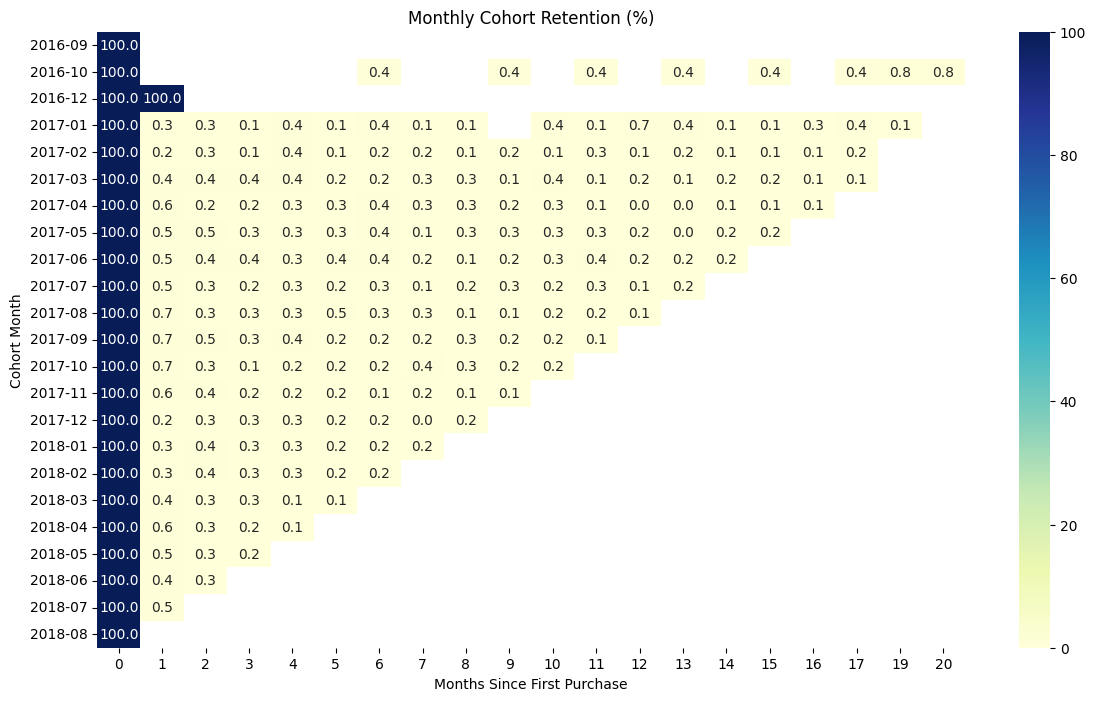

In [ ]:
# Monthly Cohort Retention(%)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.heatmap(
    cohort_percent,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

plt.title('Monthly Cohort Retention (%)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.show()

Mayoritas customer hanya melakukan satu kali pembelian, dan tingkat repeat purchase pada bulan berikutnya berada di bawah 1%. Hal ini menunjukkan bahwa model bisnis sangat bergantung pada akuisisi customer baru dan memiliki tingkat churn yang sangat tinggi.

In [ ]:
import pandas as pd

# Total revenue per state
state_sales = (
    df.groupby('customer_state')['revenue']
      .sum()
      .reset_index()
      .sort_values(by='revenue', ascending=False)
      .reset_index(drop=True)
)

# Persentase state
state_sales['state_pct'] = (
    (state_sales.index + 1) / len(state_sales) * 100
)

# Ambil top 20% state
top_20_states = state_sales[state_sales['state_pct'] <= 20]

# Hitung kontribusi sales
sales_contribution = (
    top_20_states['revenue'].sum()
    / state_sales['revenue'].sum()
    * 100
)

print(f"Top 20% states contribute {sales_contribution:.2f}% of total revenue.")

Top 20% states contribute 73.20% of total revenue.


/tmp/ipykernel_6364/1538782051.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('customer_state')['revenue']


In [ ]:
# Revenue per product category
category_sales = (
    df.groupby('product_category_name')['revenue']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

# Persentase jumlah kategori
category_sales['category_pct'] = (
    (category_sales.index + 1)
    / len(category_sales)
    * 100
)

# Ambil top 20% kategori
top_20_category = category_sales[
    category_sales['category_pct'] <= 20
]

# Hitung kontribusi revenue
revenue_contribution = (
    top_20_category['revenue'].sum()
    / category_sales['revenue'].sum()
    * 100
)

print(f"Top 20% product categories contribute {revenue_contribution:.2f}% of total revenue.")

Top 20% product categories contribute 74.29% of total revenue.


In [ ]:
customer_sales = (
    df.groupby('customer_id')['revenue']
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

customer_sales['cum_revenue_pct'] = (
    customer_sales['revenue'].cumsum()
    / customer_sales['revenue'].sum()
    * 100
)

customer_sales['customer_pct'] = (
    (customer_sales.index + 1)
    / len(customer_sales)
    * 100
)

In [ ]:
pareto = customer_sales[
    customer_sales['cum_revenue_pct'] >= 80
].iloc[0]

print(
    f"{pareto['customer_pct']:.2f}% of customers generate 80% of revenue."
)

48.85% of customers generate 80% of revenue.


In [ ]:
revenue_by_type = (
    df.groupby("customer_type")["revenue"]
      .sum()
      .reset_index()
)

revenue_by_type["Revenue %"] = (
    revenue_by_type["revenue"]
    / revenue_by_type["revenue"].sum()
    *100
)

print(revenue_by_type)

  customer_type      revenue  Revenue %
0      Existing   1786065.70  11.583992
1           New  13632329.13  88.416008


/tmp/ipykernel_6364/99501262.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("customer_type")["revenue"]


# Clustering

In [ ]:
# Make df_clean for clustering
df_clean = df.drop(columns=[
    'order_id',
    'order_hour',
    'weekday_num',
    'customer_type',
    'purchase_time_of_day',
    'delivery_time'
], errors='ignore')

In [ ]:
# Make delivery delay days
df_clean['delivery_delay_days'] = (
    df['order_estimated_delivery_date']
    - df['order_delivered_customer_date']
).dt.days

In [ ]:
# Make seller delay days
df_clean['seller_delay_days'] = (
    df['shipping_limit_date']
    - df['order_delivered_carrier_date']
).dt.days

In [ ]:
# Make df customer to aggregate columns
df_customer = (
    df_clean
    .groupby('customer_id')
    .agg(
        total_orders=('revenue', 'count'),
        total_revenue=('revenue', 'sum'),
        avg_order_value=('revenue', 'mean'),
        total_quantity=('quantity', 'sum'),
        avg_delivery_delay_days=('delivery_delay_days', 'mean'),
        avg_seller_delay_days=('seller_delay_days', 'mean'),
        total_profit=('estimated_profit', 'sum')
    )
    .reset_index()
)

In [ ]:
# Recency
max_date = df['order_date'].max()

recency = (
    df.groupby('customer_id')['order_date']
      .max()
      .reset_index()
)

recency['recency_days'] = (max_date - recency['order_date']).dt.days

# Merge recency on df_customer
df_customer = df_customer.merge(
    recency[['customer_id', 'recency_days']],
    on='customer_id',
    how='left'
)

In [ ]:
# Fill the missing with 0
df_customer = df_customer.fillna(0)
df_customer

,customer_id,total_orders,total_revenue,avg_order_value,total_quantity,avg_delivery_delay_days,avg_seller_delay_days,total_profit,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,1,4.0,3.0,129.90,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,1,4.0,2.0,18.90,114
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,1,1.0,2.0,69.00,537
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,1,11.0,5.0,25.99,321
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,1,7.0,6.0,180.00,288
...,...,...,...,...,...,...,...,...,...
93345,fffcf5a5ff07b0908bd4e2dbc735a684,2,2067.42,1033.71,2,26.0,2.0,1570.00,447
93346,fffea47cd6d3cc0a88bd621562a9d061,1,84.58,84.58,1,2.0,-7.0,64.89,262
93347,ffff371b4d645b6ecea244b27531430a,1,112.46,112.46,1,29.0,3.0,89.90,568
93348,ffff5962728ec6157033ef9805bacc48,1,133.69,133.69,1,13.0,4.0,115.00,119


In [ ]:
# Presentase missing value
((df_customer.isna().sum())/len(df))*100

,0
customer_id,0.0
total_orders,0.0
total_revenue,0.0
avg_order_value,0.0
total_quantity,0.0
avg_delivery_delay_days,0.0
avg_seller_delay_days,0.0
total_profit,0.0
recency_days,0.0


In [ ]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

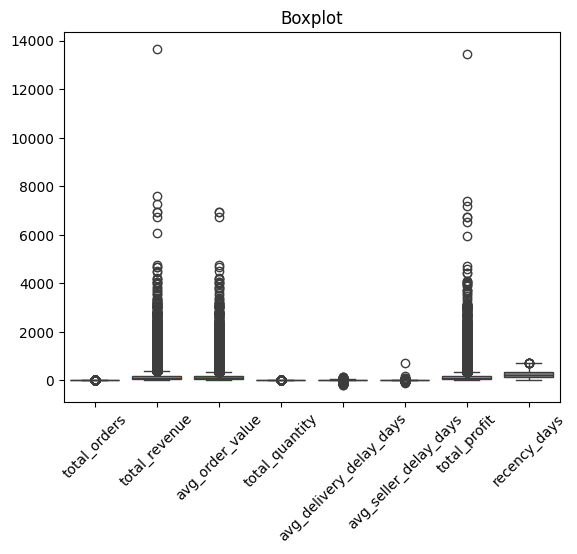

In [ ]:
# Check outlier
numeric_all = df_customer.select_dtypes(include=['number'])
sns.boxplot(numeric_all)
plt.xticks(rotation=45)
plt.title('Boxplot')
plt.show()

In [ ]:
# Check data distribution
df_customer.describe()

,total_orders,total_revenue,avg_order_value,total_quantity,avg_delivery_delay_days,avg_seller_delay_days,total_profit,recency_days
count,93350.000000,93350.000000,93350.000000,93350.0,93350.000000,93350.000000,93350.000000,93350.000000
mean,1.180386,165.167593,146.011579,1.180386,10.849931,2.833415,141.620235,237.487156
std,0.620882,226.300536,197.734467,0.620882,10.140923,4.357279,215.702028,152.593536
min,1.000000,9.590000,9.341429,1.0,-189.000000,-117.000000,0.850000,0.000000
25%,1.000000,63.010000,57.750000,1.0,6.000000,1.000000,47.650000,114.000000
50%,1.000000,107.780000,96.485000,1.0,11.000000,3.000000,89.700000,219.000000
75%,1.000000,182.505000,162.770000,1.0,16.000000,5.000000,154.697500,346.000000
max,24.000000,13664.080000,6929.310000,24.0,146.000000,698.666667,13440.000000,713.000000


In [ ]:
# Check multicollinearity
df_corr = numeric_all.corr()
df_corr

,total_orders,total_revenue,avg_order_value,total_quantity,avg_delivery_delay_days,avg_seller_delay_days,total_profit,recency_days
total_orders,1.000000,0.229767,-0.058503,1.000000,0.033579,-0.004452,0.189685,-0.011848
total_revenue,0.229767,1.000000,0.906910,0.229767,0.019481,-0.015996,0.995835,-0.004452
avg_order_value,-0.058503,0.906910,1.000000,-0.058503,0.010149,-0.016162,0.916106,0.000281
total_quantity,1.000000,0.229767,-0.058503,1.000000,0.033579,-0.004452,0.189685,-0.011848
avg_delivery_delay_days,0.033579,0.019481,0.010149,0.033579,1.000000,0.292687,0.015060,0.095275
avg_seller_delay_days,-0.004452,-0.015996,-0.016162,-0.004452,0.292687,1.000000,-0.015834,0.034231
total_profit,0.189685,0.995835,0.916106,0.189685,0.015060,-0.015834,1.000000,-0.000323
recency_days,-0.011848,-0.004452,0.000281,-0.011848,0.095275,0.034231,-0.000323,1.000000


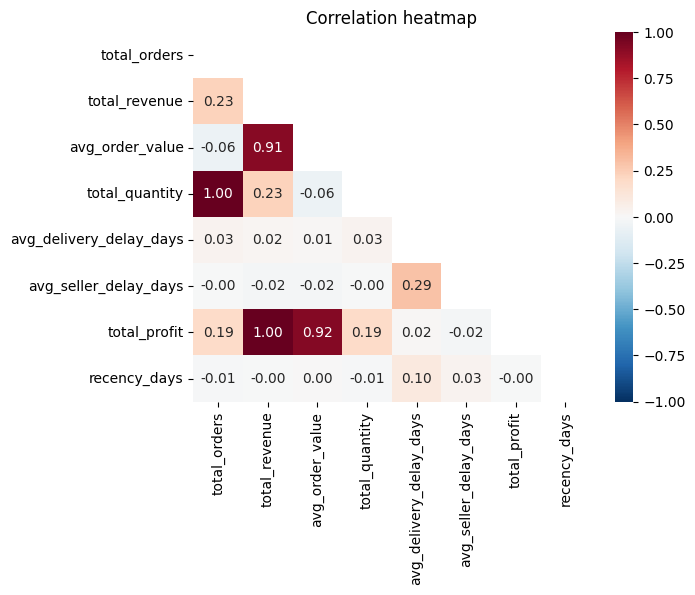

In [ ]:
# Correlation heatmap
mask = np.zeros_like(df_corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
  df_corr,
  vmin=-1,
  vmax=1,
  annot=True,
  fmt='.2f',
  mask=mask,
  cmap='RdBu_r',
)
plt.title('Correlation heatmap')
plt.show()

In [ ]:
# Drop multiconiarity
df_customer = df_customer.drop(columns=['total_quantity', 'total_profit','total_revenue'])

In [ ]:
# Load df_customer
df_customer

,customer_id,total_orders,avg_order_value,avg_delivery_delay_days,avg_seller_delay_days,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,4.0,3.0,111
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,4.0,2.0,114
2,0000f46a3911fa3c0805444483337064,1,86.22,1.0,2.0,537
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,11.0,5.0,321
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,7.0,6.0,288
...,...,...,...,...,...,...
93345,fffcf5a5ff07b0908bd4e2dbc735a684,2,1033.71,26.0,2.0,447
93346,fffea47cd6d3cc0a88bd621562a9d061,1,84.58,2.0,-7.0,262
93347,ffff371b4d645b6ecea244b27531430a,1,112.46,29.0,3.0,568
93348,ffff5962728ec6157033ef9805bacc48,1,133.69,13.0,4.0,119


In [ ]:
features = [ 'total_orders', 'avg_order_value', 'avg_delivery_delay_days', 'avg_seller_delay_days', 'recency_days' ]

X = df_customer[features].copy()
X.head()

,total_orders,avg_order_value,avg_delivery_delay_days,avg_seller_delay_days,recency_days
0,1,141.90,4.0,3.0,111
1,1,27.19,4.0,2.0,114
2,1,86.22,1.0,2.0,537
3,1,43.62,11.0,5.0,321
4,1,196.89,7.0,6.0,288


In [ ]:
# Transformation
X_transformed = X.copy()
X_transformed.head(3)

,total_orders,avg_order_value,avg_delivery_delay_days,avg_seller_delay_days,recency_days
0,1,141.90,4.0,3.0,111
1,1,27.19,4.0,2.0,114
2,1,86.22,1.0,2.0,537


In [ ]:
# Standardscaler
float64_columns = X_transformed.columns

for c in float64_columns:
  scaler = StandardScaler()
  X_transformed[c] = scaler.fit_transform(X_transformed[[c]])

X_transformed.describe()

,total_orders,avg_order_value,avg_delivery_delay_days,avg_seller_delay_days,recency_days
count,9.335000e+04,9.335000e+04,9.335000e+04,9.335000e+04,9.335000e+04
mean,-4.932316e-17,1.272659e-16,-3.151202e-17,7.581152e-17,-1.522320e-17
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,-2.905330e-01,-6.911839e-01,-1.970738e+01,-2.750204e+01,-1.556347e+00
25%,-2.905330e-01,-4.463666e-01,-4.782559e-01,-4.207730e-01,-8.092598e-01
50%,-2.905330e-01,-2.504715e-01,1.479844e-02,3.823156e-02,-1.211536e-01
75%,-2.905330e-01,8.475260e-02,5.078528e-01,4.972361e-01,7.111273e-01
max,3.675376e+01,3.430527e+01,1.332727e+01,1.596953e+02,3.116222e+00


# Select model

In [ ]:
# Select model
# Agglomerative
# Dikarenakan google colab tidak bisa dirun bagian ini karena membutuhkan RAM yang sangat besar maka diambil sample
# Sampling hanya untuk Agglomerative agar tidak overload RAM
sample_idx = np.random.choice(len(X_transformed), 3000, replace=False)
X_sample = X_transformed.iloc[sample_idx]

agg = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

agg.fit(X_sample)

AgglomerativeClustering(n_clusters=4)

In [ ]:
# Evaluate
# Silhouette Score
silhouette_score(X_sample, agg.labels_)

np.float64(0.2175658713963701)

                 0
count  3000.000000
mean      0.217566
std       0.191170
min      -0.397249
25%       0.088306
50%       0.245275
75%       0.368675
max       0.543270


<Axes: ylabel='Count'>

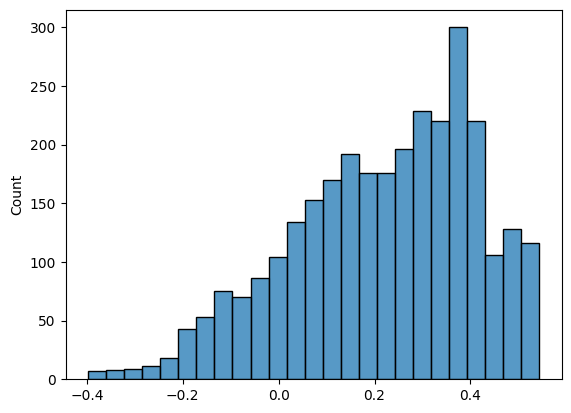

In [ ]:
silhouette_score_per_data = silhouette_samples(X_sample, agg.labels_)

print(pd.DataFrame(silhouette_score_per_data).describe())

sns.histplot(silhouette_score_per_data)

In [ ]:
# Calinski-Harabasz Score
calinski_harabasz_score(X_sample, agg.labels_)

np.float64(506.2969400840948)

In [ ]:
# Find optimal number of cluster
n_clusters = range(2, 11)
silhouette_scores = []
calinski_harabasz_scores = []

for n in n_clusters:
  print('Generating', n, 'clusters...')
  agg = AgglomerativeClustering(
    n_clusters=n,
    metric='euclidean',
    linkage='ward',
    compute_distances=True,
  )

  agg.fit(X_sample)

  silhouette_scores.append(silhouette_score(X_sample, agg.labels_))
  calinski_harabasz_scores.append(
    calinski_harabasz_score(X_sample, agg.labels_)
  )

Generating 2 clusters...
Generating 3 clusters...
Generating 4 clusters...
Generating 5 clusters...
Generating 6 clusters...
Generating 7 clusters...
Generating 8 clusters...
Generating 9 clusters...
Generating 10 clusters...


<Axes: >

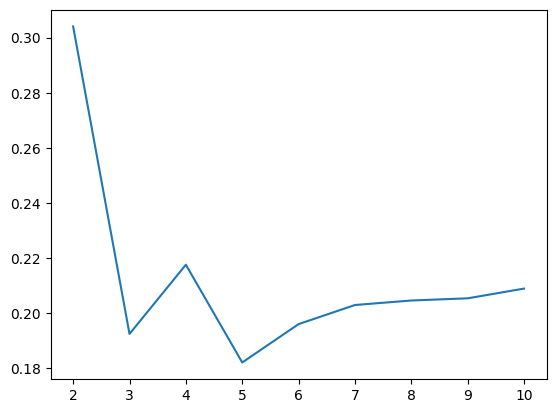

In [ ]:
# Evaluate
# silhouette_scores
sns.lineplot(x=n_clusters, y=silhouette_scores)

<Axes: >

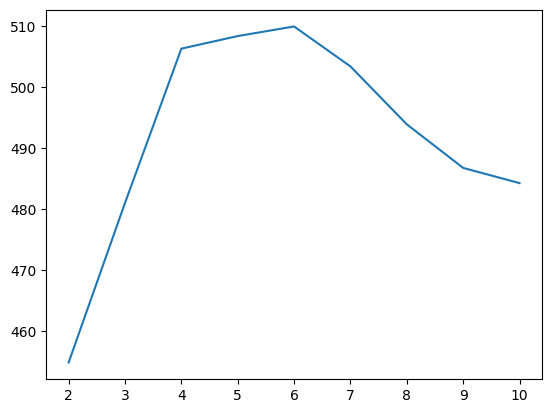

In [ ]:
# calinski_harabasz_scores
sns.lineplot(x=n_clusters, y=calinski_harabasz_scores)

In [ ]:
# Generate Final cluster
agg = AgglomerativeClustering(
  n_clusters=2,
  metric='euclidean',
  linkage='ward',
  compute_distances=True,
)

agg.fit(X_sample)

AgglomerativeClustering(compute_distances=True)

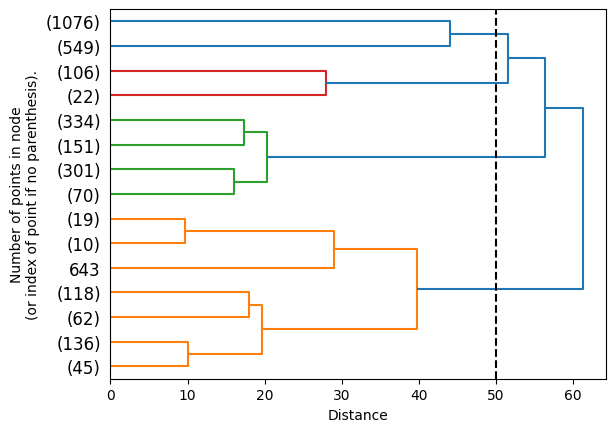

In [ ]:
# Visualize
# Dendogram
def plot_dendrogram(model, **kwargs):
  counts = np.zeros(model.children_.shape[0])
  n_samples = len(model.labels_)
  for i, merge in enumerate(model.children_):
    current_count = 0
    for child_idx in merge:
      if child_idx < n_samples:
        current_count += 1  # leaf node
      else:
        current_count += counts[child_idx - n_samples]
    counts[i] = current_count

  linkage_matrix = np.column_stack([
    model.children_,
    model.distances_,
    counts,
  ]).astype(float)

  dendrogram(linkage_matrix, orientation='right', **kwargs)

plot_dendrogram(agg, truncate_mode='level', p=3)
plt.xlabel('Distance')
plt.ylabel('Number of points in node\n(or index of point if no parenthesis).')

plt.axvline(x=50, color='black', linestyle='--')

plt.show()

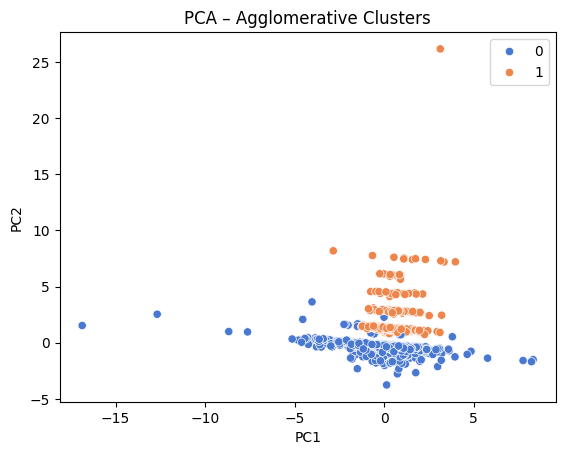

In [ ]:
# Generate 2D scatter plot using PCA
pca = PCA(n_components=5, random_state=11)
X_pca = pca.fit_transform(X_sample)

X_pca_1 = [row[0] for row in X_pca]
X_pca_2 = [row[1] for row in X_pca]

ax = sns.scatterplot(
  x=X_pca_1,
  y=X_pca_2,
  hue=agg.labels_,
  palette='muted',
)
ax.set(
  xlabel='PC1',
  ylabel='PC2',
)
plt.title('PCA – Agglomerative Clusters')
plt.show()

In [ ]:
# K-means
n_clusters = range(2, 11)
inertia_scores = []
silhouette_scores_kmeans = []
calinski_scores_kmeans = []

for n in n_clusters:
  print('Generating', n, 'clusters...')
  km_tmp = KMeans(
    n_clusters=n,
    algorithm='lloyd',
    random_state=11,
  )

  km_tmp.fit(X_transformed)

  inertia_scores.append(km_tmp.inertia_)
  silhouette_scores_kmeans.append(
    silhouette_score(X_transformed, km_tmp.labels_)
  )
  calinski_scores_kmeans.append(
    calinski_harabasz_score(X_transformed, km_tmp.labels_)
  )

Generating 2 clusters...
Generating 3 clusters...
Generating 4 clusters...
Generating 5 clusters...
Generating 6 clusters...
Generating 7 clusters...
Generating 8 clusters...
Generating 9 clusters...
Generating 10 clusters...


<Axes: >

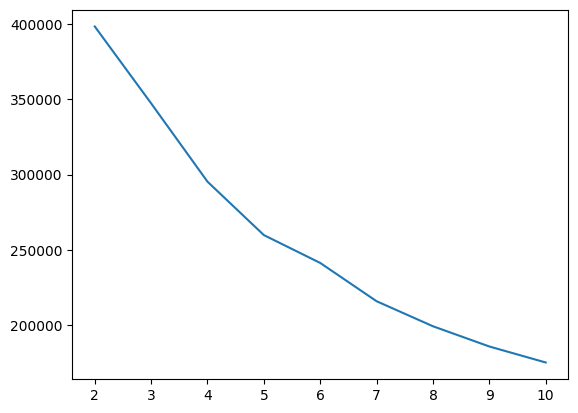

In [ ]:
# Evaluate
# Elbow method
sns.lineplot(x=n_clusters, y=inertia_scores)

Nilai k optimal (Elbow method) adalah 5

<Axes: >

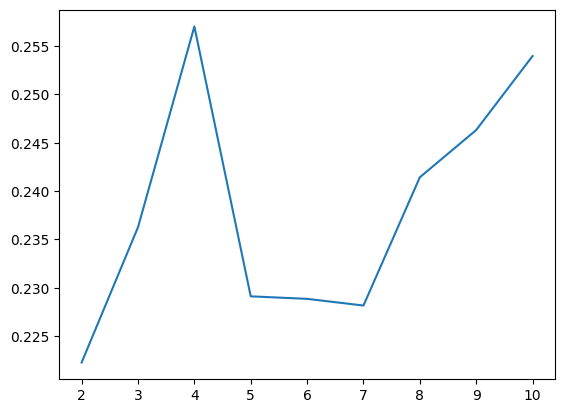

In [ ]:
# silhouette_scores_kmeans
sns.lineplot(x=n_clusters, y=silhouette_scores_kmeans)

Nilai k optimal untuk Silhouette score adlaah 4

<Axes: >

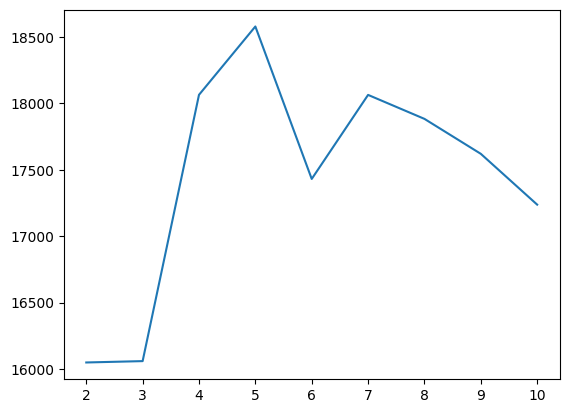

In [ ]:
# Calinski Harabasz scores
sns.lineplot(x=n_clusters, y=calinski_scores_kmeans)

Nilai k optimal dari Calinski Harabaz Index yaitu 5

Total cluster yang digunakan adalah 5. Hal ini berdasarkan 2 dari 3 method menunjukan 5 adalah cluster yang optimal. Metode yang dimasksud adalah Elbow method dan Calinski Harabaz index dengan nilai k optimal yaitu 5

In [ ]:
# Generate final cluster(k-means)
km = KMeans(
  n_clusters=5,
  algorithm='lloyd',
  random_state=11,
)

km.fit(X_transformed)

KMeans(n_clusters=5, random_state=11)

In [ ]:
#Visualized
km.cluster_centers_

array([[-0.13132522, -0.12938412,  0.21264217,  0.13132684,  1.13339518],
       [-0.15218292, -0.12186247, -1.00169027, -0.50078204, -0.52169524],
       [-0.23095731,  4.6821105 ,  0.04622668, -0.05070673,  0.03693397],
       [ 4.32036717, -0.23818464,  0.15584084, -0.03419792, -0.05066072],
       [-0.11595219, -0.09982907,  0.49447011,  0.23951772, -0.62382915]])

In [ ]:
pca.transform(km.cluster_centers_)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


array([[ 0.4661048 , -0.17643479,  1.05079954, -0.17497821,  0.05829965],
       [-1.20759953,  0.00632095, -0.28102371, -0.11327162,  0.09994217],
       [ 0.07271036, -1.37278466, -0.02181643,  4.46727588,  0.42765615],
       [ 0.69636833,  4.1742543 , -0.12616474,  0.76526429,  0.16412145],
       [ 0.38440898, -0.16923377, -0.72424465, -0.14742873, -0.08939094]])

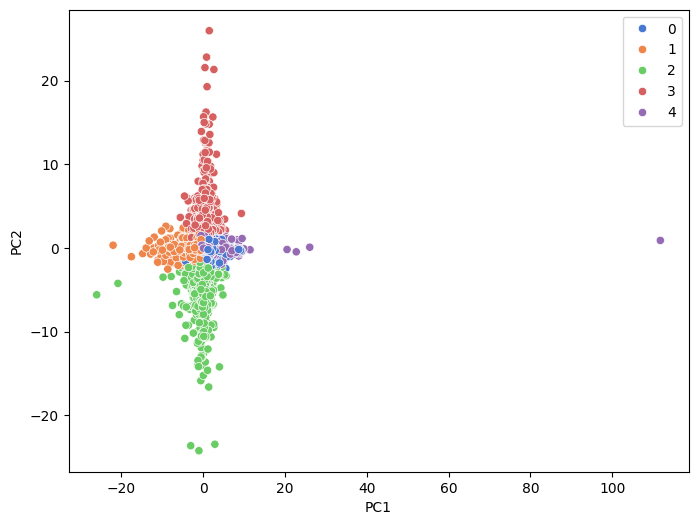

In [ ]:
# PCA
pca = PCA(n_components=2, random_state=11)
X_pca = pca.fit_transform(X_transformed)

plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=km.labels_,
    palette='muted',
)
ax.set(
  xlabel='PC1',
  ylabel='PC2',
)
plt.show()

Dari 5 cluster yang dibentuk terdapat 2 cluster yang sangat mirip dan bertumpuk/tidak terpisah sempurna namun masih bisa dibedakan

In [ ]:
# Interpretasi
X_with_cluster = X.copy()
X_with_cluster['cluster_kmeans'] = km.labels_

X_with_cluster.head()

,total_orders,avg_order_value,avg_delivery_delay_days,avg_seller_delay_days,recency_days,cluster_kmeans
0,1,141.90,4.0,3.0,111,1
1,1,27.19,4.0,2.0,114,1
2,1,86.22,1.0,2.0,537,0
3,1,43.62,11.0,5.0,321,0
4,1,196.89,7.0,6.0,288,0


<Axes: ylabel='total_orders'>

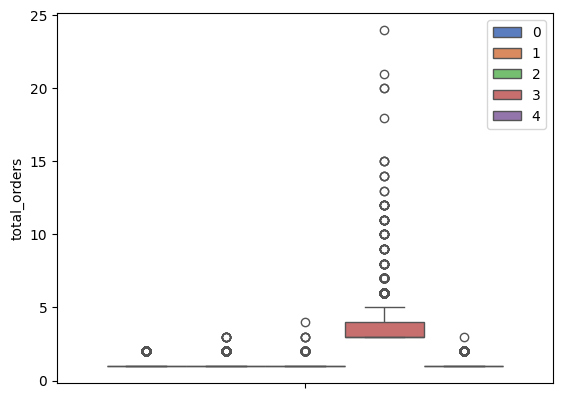

In [ ]:
# Boxplot by total order
sns.boxplot(y=X_with_cluster['total_orders'], hue=km.labels_, palette='muted')


Cluster 3 merupakan cluster dengan customer yang memliki total order terbanyak

<Axes: ylabel='avg_order_value'>

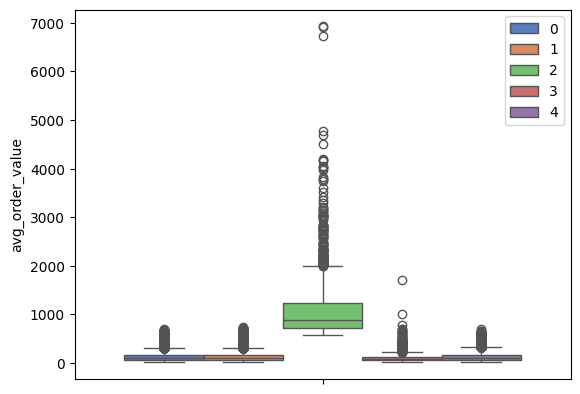

In [ ]:
# Boxplot by average order value
sns.boxplot(y=X_with_cluster['avg_order_value'], hue=km.labels_, palette='muted')

Cluster 2 merupakan cluster yang memiliki order value tertinggi

<Axes: ylabel='avg_delivery_delay_days'>

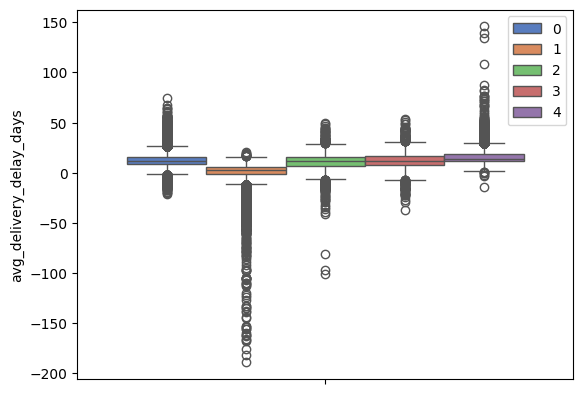

In [ ]:
# Boxplot by average delays day
sns.boxplot(y=X_with_cluster['avg_delivery_delay_days'], hue=km.labels_, palette='muted')

Cluster 1 memiliki keterlambatan pengiriman tertinggi

<Axes: ylabel='avg_seller_delay_days'>

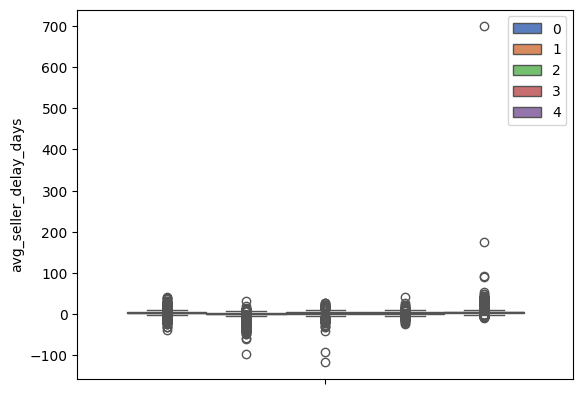

In [ ]:
# Boxplot by average seller delay days
sns.boxplot(y=X_with_cluster['avg_seller_delay_days'], hue=km.labels_, palette='muted')

CLuster 1 dan 2 memiliki keterlambatan seller tertinggi

<Axes: ylabel='recency_days'>

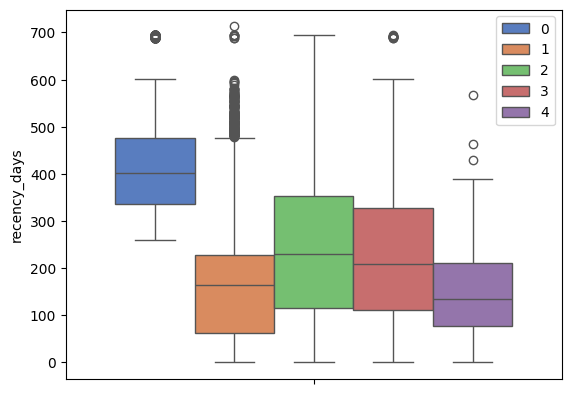

In [ ]:
# Boxplot by recency day
sns.boxplot(y=X_with_cluster['recency_days'], hue=km.labels_, palette='muted')

Cluster 1 dan 4 merupakan new customer, cluster 0 sudah lama tidak berbelanja

Metode yang digunakan untuk clustering ini adalah k-means karena untuk agglomerative hanya menggunakan sample sehingga hasil kurang dapat dijelaskan secara seluruhnya sedangkan k-means menggunakan seluruh data sehingga hasil menjadi lebih valid

In [ ]:
df_customer['cluster'] = km.labels_

In [ ]:
# Cluster summary
cluster_summary = (
    df_customer
    .groupby('cluster')
    .agg(
        customers=('customer_id', 'count'),
        avg_total_orders=('total_orders', 'mean'),
        avg_order_value=('avg_order_value', 'mean'),
        avg_delivery_delay=('avg_delivery_delay_days', 'mean'),
        avg_seller_delay=('avg_seller_delay_days', 'mean'),
        avg_recency=('recency_days', 'mean')
    )
    .round(2)
)

cluster_summary

,customers,avg_total_orders,avg_order_value,avg_delivery_delay,avg_seller_delay,avg_recency
cluster,,,,,,
0,29912,1.10,120.41,13.02,3.41,410.62
1,23891,1.09,121.88,0.69,0.65,158.29
2,2328,1.04,1071.25,11.31,2.61,243.10
3,2799,3.86,98.91,12.43,2.68,229.76
4,34420,1.11,126.26,15.85,3.87,142.25


In [ ]:
# Make customer  of customer
cluster_summary['customer_pct'] = (
    cluster_summary['customers'] / cluster_summary['customers'].sum() * 100
).round(2)

cluster_summary

,customers,avg_total_orders,avg_order_value,avg_delivery_delay,avg_seller_delay,avg_recency,customer_pct
cluster,,,,,,,
0,29912,1.10,120.41,13.02,3.41,410.62,32.04
1,23891,1.09,121.88,0.69,0.65,158.29,25.59
2,2328,1.04,1071.25,11.31,2.61,243.10,2.49
3,2799,3.86,98.91,12.43,2.68,229.76,3.00
4,34420,1.11,126.26,15.85,3.87,142.25,36.87


In [ ]:
# Make customer is repeat
df_customer['is_repeat'] = (df_customer['total_orders'] > 1).astype(int)

repeat_summary = (
    df_customer
    .groupby('cluster')['is_repeat']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name='repeat_rate_%')
)

repeat_summary

,cluster,repeat_rate_%
0,0,9.90
1,1,8.55
2,2,3.44
3,3,100.00
4,4,10.83


In [ ]:
# Megre repeat on cluster summary
cluster_summary = cluster_summary.merge(
    repeat_summary,
    on='cluster',
    how='left'
)

In [ ]:
# Late delivery
df_customer['late_delivery'] = (df_customer['avg_delivery_delay_days'] < 0).astype(int)

late_summary = (
    df_customer
    .groupby('cluster')['late_delivery']
    .mean()
    .mul(100)
    .round(2)
    .reset_index(name='late_delivery_rate_%')
)

cluster_summary = cluster_summary.merge(
    late_summary,
    on='cluster',
    how='left'
)

In [ ]:
cluster_summary

,cluster,customers,avg_total_orders,avg_order_value,avg_delivery_delay,avg_seller_delay,avg_recency,customer_pct,repeat_rate_%,late_delivery_rate_%
0,0,29912,1.10,120.41,13.02,3.41,410.62,32.04,9.90,1.43
1,1,23891,1.09,121.88,0.69,0.65,158.29,25.59,8.55,28.36
2,2,2328,1.04,1071.25,11.31,2.61,243.10,2.49,3.44,8.33
3,3,2799,3.86,98.91,12.43,2.68,229.76,3.00,100.00,5.29
4,4,34420,1.11,126.26,15.85,3.87,142.25,36.87,10.83,0.01


In [ ]:
# Uji kluskal walis
from scipy.stats import kruskal

groups = [
    df_customer[df_customer['cluster'] == i]['avg_delivery_delay_days'].dropna()
    for i in sorted(df_customer['cluster'].unique())
]

h_stat, p_value = kruskal(*groups)

print("H-statistic:", h_stat)
print("p-value:", p_value)

H-statistic: 45008.23863863553
p-value: 0.0


In [ ]:
# Customer is churn
df_customer['is_churn'] = (df_customer['total_orders'] == 1).astype(int)

In [ ]:
# Make fast delivery and late delivery by quantile
q_low  = df_customer['avg_delivery_delay_days'].quantile(0.25)
q_high = df_customer['avg_delivery_delay_days'].quantile(0.75)

fast_delivery = df_customer[df_customer['avg_delivery_delay_days'] >= q_high]
late_delivery = df_customer[df_customer['avg_delivery_delay_days'] <= q_low]

In [ ]:
# Uji Mann Whitney U
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(
    late_delivery['is_churn'],
    fast_delivery['is_churn'],
    alternative='two-sided'
)

print("U-statistic:", u_stat)
print("p-value:", p_value)

U-statistic: 309588505.5
p-value: 1.0089080333440036e-25


In [ ]:
#v Make label delivery
q_low  = cluster_summary['avg_delivery_delay'].quantile(0.25)
q_high = cluster_summary['avg_delivery_delay'].quantile(0.75)

def label_delivery(x):
    if x >= q_high:
        return 'fast_delivery'
    elif x <= q_low:
        return 'late_delivery'
    else:
        return 'on_time_delivery'

cluster_summary['delivery_label'] = (
    cluster_summary['avg_delivery_delay']
    .apply(label_delivery)
)

In [ ]:
cluster_summary

,cluster,customers,avg_total_orders,avg_order_value,avg_delivery_delay,avg_seller_delay,avg_recency,customer_pct,repeat_rate_%,late_delivery_rate_%,delivery_label
0,0,29912,1.10,120.41,13.02,3.41,410.62,32.04,9.90,1.43,fast_delivery
1,1,23891,1.09,121.88,0.69,0.65,158.29,25.59,8.55,28.36,late_delivery
2,2,2328,1.04,1071.25,11.31,2.61,243.10,2.49,3.44,8.33,late_delivery
3,3,2799,3.86,98.91,12.43,2.68,229.76,3.00,100.00,5.29,on_time_delivery
4,4,34420,1.11,126.26,15.85,3.87,142.25,36.87,10.83,0.01,fast_delivery


In [ ]:
# Label of cluster
cluster_label_map = {
    0: 'Dormant Customers',
    1: 'New Customers (Poor delivery experience)',
    2: 'High value customers',
    3: 'Loyal customers',
    4: 'New customers (Fast delivery)'
}

df_customer['cluster_label'] = df_customer['cluster'].map(cluster_label_map)

In [ ]:
df_customer

,customer_id,total_orders,avg_order_value,avg_delivery_delay_days,avg_seller_delay_days,recency_days,cluster,is_repeat,late_delivery,is_churn,cluster_label
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,4.0,3.0,111,1,0,0,1,New Customers (Poor delivery experience)
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,4.0,2.0,114,1,0,0,1,New Customers (Poor delivery experience)
2,0000f46a3911fa3c0805444483337064,1,86.22,1.0,2.0,537,0,0,0,1,Dormant Customers
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,11.0,5.0,321,0,0,0,1,Dormant Customers
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,7.0,6.0,288,0,0,0,1,Dormant Customers
...,...,...,...,...,...,...,...,...,...,...,...
93345,fffcf5a5ff07b0908bd4e2dbc735a684,2,1033.71,26.0,2.0,447,2,1,0,0,High value customers
93346,fffea47cd6d3cc0a88bd621562a9d061,1,84.58,2.0,-7.0,262,1,0,0,1,New Customers (Poor delivery experience)
93347,ffff371b4d645b6ecea244b27531430a,1,112.46,29.0,3.0,568,0,0,0,1,Dormant Customers
93348,ffff5962728ec6157033ef9805bacc48,1,133.69,13.0,4.0,119,4,0,0,1,New customers (Fast delivery)


In [ ]:
df_customer.to_csv("df_customer.csv", index=False)

from google.colab import files
files.download("df_customer.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Merge cluster labe;=l
df = df.merge(
    df_customer[['customer_id', 'cluster_label']],
    on='customer_id',
    how='left'
)

df

,order_id,order_item_id,customer_id,seller_id,product_id,order_ts,order_date,order_week,order_month,order_hour,weekday_num,weekday_name,quantity,order_approved_at,shipping_limit_date,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,revenue,customer_city,customer_state,seller_city,seller_state,order_sequence,cohort_month,customer_type,product_category_name,product_description_lenght,product_photos_qty,product_weight_g,product_category_name_english,purchase_time_of_day,order_to_delivery_days,is_late_delivery,is_late_seller,estimated_profit,is_loss,cohort_index,cluster_label
0,f1dc649e1ea6789e7eddbdaf40aaddb1,1,00d447911e5d5ae87480df8734b915f2,c864036feaab8c1659f65ea4faebe1da,55552e80f046fafe13e130e6a07745e2,2018-08-01 20:21:24,2018-08-01,2018-07-30/2018-08-05,2018-08,20,3,Wed,1,2018-08-03 04:35:15,2018-08-07 04:35:15,2018-08-03 12:49:00,2018-08-09 20:18:45,2018-08-28,219.90,60.75,280.65,niteroi,RJ,campo largo,PR,1,2018-08,New,esporte_lazer,1149.0,8.0,9950.0,sports_leisure,malam,7,0,0,219.90,0,0,New customers (Fast delivery)
1,d95b2210692db91db720c1ef8b02c1cd,1,00d474cea9ceb88b7175d564b081dfa3,69a43819c758c65a5befb0b471c954d7,9867ef342d95bb4f9b6ebf39bad864f7,2017-06-15 11:48:29,2017-06-15,2017-06-12/2017-06-18,2017-06,11,4,Thu,1,2017-06-15 12:03:08,2017-06-21 12:03:08,2017-06-16 17:22:10,2017-06-23 12:32:23,2017-07-20,99.95,15.45,115.40,imbituba,SC,apucarana,PR,1,2017-06,New,fashion_bolsas_e_acessorios,262.0,4.0,317.0,fashion_bags_accessories,pagi,8,0,0,99.95,0,0,Dormant Customers
2,fd6ae3b1149c4a3a920086befc628e3d,1,00d4ef3e086e2191c3fb6e7b0d2a1c75,aafe36600ce604f205b86b5084d3d767,57e089e3103f5cda6a4ce23b77399bdb,2018-06-30 12:19:32,2018-06-30,2018-06-25/2018-07-01,2018-06,12,6,Sat,1,2018-07-05 16:26:52,2018-07-05 04:31:45,2018-07-04 12:02:00,2018-07-10 23:19:36,2018-07-27,47.90,19.53,67.43,bauru,SP,sao jose,SC,1,2018-06,New,bebes,1194.0,4.0,650.0,baby,sore,10,0,0,47.90,0,0,New customers (Fast delivery)
3,e7ce593c46f447cf67788cfb73581ad7,1,00d76f8bb8df7e07711da4076c52ffe0,951e8cef368f09bb3f3d03c00ca4702c,45f4784fe1b64e1e5a1b9dade6a83e88,2018-07-14 12:22:31,2018-07-14,2018-07-09/2018-07-15,2018-07,12,6,Sat,1,2018-07-17 04:32:00,2018-07-23 04:32:00,2018-07-17 13:53:00,2018-07-20 16:41:36,2018-08-01,105.99,18.84,124.83,ribeirao das neves,MG,ibitinga,SP,1,2018-07,New,cama_mesa_banho,119.0,1.0,2250.0,bed_bath_table,sore,6,0,0,105.99,0,0,New customers (Fast delivery)
4,1657d073874b59831bbf61d290efb44a,1,00d7812c158831a996a6b3f4698643b5,9f505651f4a6abe901a56cdc21508025,d33a74e1b6cfc152b6b3f43324d54987,2018-08-19 18:12:07,2018-08-19,2018-08-13/2018-08-19,2018-08,18,7,Sun,1,2018-08-20 13:40:15,2018-08-22 12:50:18,2018-08-20 16:07:00,2018-08-21 22:45:36,2018-08-28,14.99,8.29,23.28,jundiai,SP,sao paulo,SP,1,2018-08,New,informatica_acessorios,366.0,1.0,350.0,computers_accessories,malam,2,0,0,14.99,0,0,New Customers (Poor delivery experience)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110184,fc0c50f90120412d596dbda411f6fbe4,1,00d012266be1430eec790d0f405a836c,128639473a139ac0f3e5f5ade55873a5,82e4ad16521ca131d95e198d507db370,2018-04-19 13:15:35,2018-04-19,2018-04-16/2018-04-22,2018-04,13,4,Thu,1,2018-04-19 14:30:50,2018-04-25 13:33:15,2018-04-19 23:48:32,2018-04-26 22:29:33,2018-05-15,18.90,18.23,37.13,porto alegre,RS,maringa,PR,1,2018-04,New,eletronicos,343.0,1.0,150.0,electronics,sore,7,0,0,18.90,0,0,New customers (Fast delivery)
110185,7d1ac7d65c6b5d59a9ac241fa41da57d,1,00d03b5e33f8987549c5590313a4ef21,b76dba6c951ab00dc4edf0a1aa88037e,4633dfeb3a2588bdb52af32d504b44eb,2017-06-16 23:17:41,2017-06-16,2017-06-12/2017-06-18,2017-06,23,5,Fri,1,2017-06-16 23:30:10,2017-07-05 23:30:10,2017-06-19 11:15:51,2017-06-29 11:06:37,2017-08-02,19.99,15.10,35.09,pantano grande,RS,sao paulo,SP,1,2017-06,New,telefonia_fixa,218.0,4.0,150.0,fixed_telephony,malam,12,0,0,19.99,0,0,D

In [ ]:
df.to_csv("data.csv", index=False)

from google.colab import files
files.download("data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_clean.to_csv("df_clean.csv", index=False)

from google.colab import files
files.download("df_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Regression

In [ ]:
# Change order date to year and month
df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month

df['order_ts'] = pd.to_datetime(df['order_ts'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

df['order_to_delivery_days'] = (
    df['order_delivered_customer_date']
    - df['order_ts']
).dt.days

df = df[df['order_to_delivery_days'].notna()]

In [ ]:
# Make column delivery delay days
df['delivery_delay_days'] = (
    df['order_estimated_delivery_date']
    - df['order_delivered_customer_date']
).dt.days

In [ ]:
# Megre total orders
df_orders = (
    df.groupby(['product_category_name', 'year', 'month'])
      .agg(
          total_orders=('order_id', 'nunique')
      )
      .reset_index()
)

In [ ]:
# Merge price and freight value
df_price_freight = (
    df.groupby(['product_category_name', 'year', 'month'])
      .agg(
          avg_price=('price', 'mean'),
          avg_freight_value=('freight_value', 'mean')
      )
      .reset_index()
)

In [ ]:
# Merge delivery time
df['year'] = df['order_ts'].dt.year
df['month'] = df['order_ts'].dt.month

delivery_agg = (
    df
    .groupby(['product_category_name', 'year', 'month'])
    .agg(
        avg_delivery_time=('order_to_delivery_days', 'mean')
    )
    .reset_index()
)


In [ ]:
# Handling missing value
df['product_description_lenght'] = df['product_description_lenght'].fillna(0)
df['product_photos_qty'] = df['product_photos_qty'].fillna(0)

In [ ]:
# Merge description length
df_description = (
    df.groupby(['product_category_name', 'year', 'month'])
    .agg(
        avg_description_length=('product_description_lenght', 'mean'),
        avg_product_photos_qty=('product_photos_qty', 'mean')
    )
    .reset_index()
)

In [ ]:
# Merge delavy day
df_delivery = (
    df.groupby(['product_category_name', 'year', 'month'])
    .agg(
        avg_delay_day=('delivery_delay_days', 'mean'),
    )
    .reset_index()
)

In [ ]:
# Merge all table
df_regression = (
    df_orders
      .merge(df_delivery, on=['product_category_name', 'year', 'month'], how='left')
      .merge(delivery_agg, on=['product_category_name', 'year', 'month'], how='left')
      .merge(df_description, on=['product_category_name', 'year', 'month'], how='left')
      .merge(df_price_freight, on=['product_category_name', 'year', 'month'], how='left')
)

In [ ]:
df_regression.head()

,product_category_name,year,month,total_orders,avg_delay_day,avg_delivery_time,avg_description_length,avg_product_photos_qty,avg_price,avg_freight_value
0,agro_industria_e_comercio,2017,1,2,20.000000,8.000000,380.000000,1.00,21.990,13.93
1,agro_industria_e_comercio,2017,2,7,16.571429,12.571429,415.428571,1.00,32.120,15.18
2,agro_industria_e_comercio,2017,3,2,11.500000,8.500000,439.000000,1.50,40.995,14.35
3,agro_industria_e_comercio,2017,5,4,14.000000,11.250000,458.250000,2.75,394.985,45.95
4,agro_industria_e_comercio,2017,6,1,17.000000,9.000000,471.000000,1.00,1390.000,32.05


In [ ]:
df_regression.isna().sum()

,0
product_category_name,0
year,0
month,0
total_orders,0
avg_delay_day,0
avg_delivery_time,0
avg_description_length,0
avg_product_photos_qty,0
avg_price,0
avg_freight_value,0


In [ ]:
# Drop year and month
df_regression = df_regression.drop(columns=['year', 'month'])

In [ ]:
df_regression.head()

,product_category_name,total_orders,avg_delay_day,avg_delivery_time,avg_description_length,avg_product_photos_qty,avg_price,avg_freight_value
0,agro_industria_e_comercio,2,20.000000,8.000000,380.000000,1.00,21.990,13.93
1,agro_industria_e_comercio,7,16.571429,12.571429,415.428571,1.00,32.120,15.18
2,agro_industria_e_comercio,2,11.500000,8.500000,439.000000,1.50,40.995,14.35
3,agro_industria_e_comercio,4,14.000000,11.250000,458.250000,2.75,394.985,45.95
4,agro_industria_e_comercio,1,17.000000,9.000000,471.000000,1.00,1390.000,32.05


In [ ]:
df_regression.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_category_name   1273 non-null   object 
 1   total_orders            1273 non-null   int64  
 2   avg_delay_day           1273 non-null   float64
 3   avg_delivery_time       1273 non-null   float64
 4   avg_description_length  1273 non-null   float64
 5   avg_product_photos_qty  1273 non-null   float64
 6   avg_price               1273 non-null   float64
 7   avg_freight_value       1273 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 79.7+ KB


In [ ]:
# make group for category prouct
category_total = (
    df_regression
    .groupby('product_category_name')['total_orders']
    .sum()
)

rare_categories = category_total[category_total < 30].index

df_regression['product_category_grouped'] = (
    df_regression['product_category_name']
    .replace(rare_categories, 'other')
)

In [ ]:
# make dummies of product category name
X = pd.get_dummies(
    df_regression.drop(columns=['total_orders', 'product_category_name']),
    columns=['product_category_grouped'],
    drop_first=True
)

y = df_regression['total_orders']

In [ ]:
# Split test and train
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# VIF score
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_features = df_regression[[
    'avg_delay_day',
    'avg_price',
    'avg_freight_value',
    'avg_delivery_time',
    'avg_description_length',
    'avg_product_photos_qty'
]]

X_num = num_features.to_numpy(dtype=float)

vif_df = pd.DataFrame({
    'feature': num_features.columns,
    'vif_score': [
        variance_inflation_factor(X_num, i)
        for i in range(X_num.shape[1])
    ]
})

vif_df

,feature,vif_score
0,avg_delay_day,3.067598
1,avg_price,2.141448
2,avg_freight_value,6.255433
3,avg_delivery_time,4.793442
4,avg_description_length,4.340628
5,avg_product_photos_qty,4.356866


In [ ]:
# Check data type
num_features.dtypes

,0
avg_delay_day,float64
avg_price,float64
avg_freight_value,float64
avg_delivery_time,float64
avg_description_length,float64
avg_product_photos_qty,float64


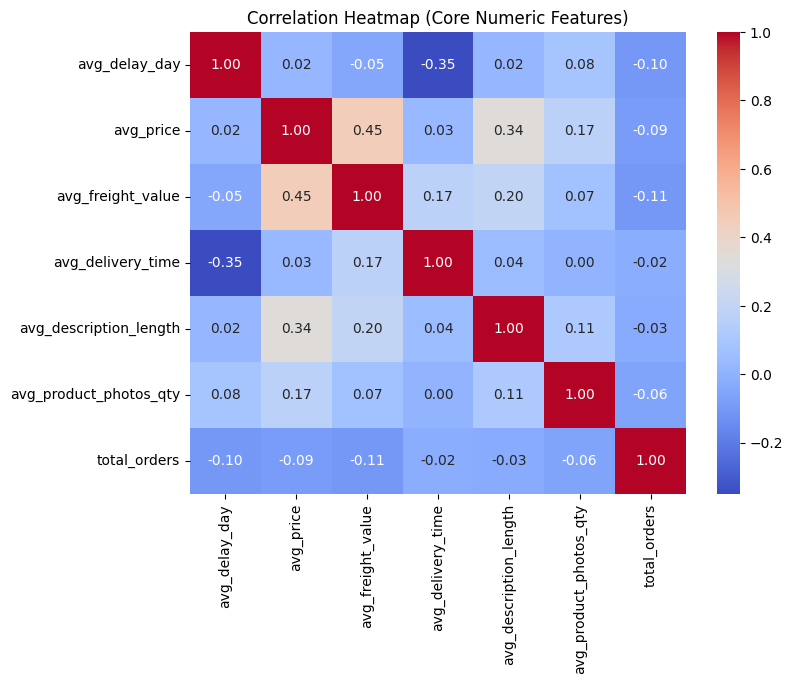

In [ ]:
# Korelation by heatmap
corr_features = X[[
    'avg_delay_day',
    'avg_price',
    'avg_freight_value',
    'avg_delivery_time',
    'avg_description_length',
    'avg_product_photos_qty'
]]

corr_df = pd.concat([corr_features, y], axis=1)
corr = corr_df.corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (Core Numeric Features)')
plt.show()


In [ ]:
# Standarscaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
# RMSE, MAE, and R2 of Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_pred_lr = linreg.predict(X_test_scaled)

print("Linear RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear MAE :", mean_absolute_error(y_test, y_pred_lr))
print("Linear R2  :", r2_score(y_test, y_pred_lr))

Linear RMSE: 80.33265156210929


NameError: name 'mean_absolute_error' is not defined

In [ ]:
# Choose the best alpha
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge(random_state=42)

param_grid = {
    'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 5, 20, 50, 100]
}

ridge_cv = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

ridge_cv.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Ridge(random_state=42),
             param_grid={'alpha': [1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 5, 20,
                                   50, 100]},
             scoring='neg_root_mean_squared_error')

In [ ]:
# the complete results
pd.DataFrame(ridge_cv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003428,0.001464,0.001063,0.000106,0.00001,{'alpha': 1e-05},-67.248848,-68.631522,-75.372978,-68.074741,-70.409484,-69.947515,2.904169,6
1,0.002439,0.000030,0.000991,0.000015,0.00010,{'alpha': 0.0001},-67.248846,-68.631520,-75.372976,-68.074741,-70.409487,-69.947514,2.904169,5
2,0.002488,0.000058,0.000980,0.000011,0.00100,{'alpha': 0.001},-67.248825,-68.631497,-75.372957,-68.074739,-70.409513,-69.947506,2.904169,4
3,0.002389,0.000019,0.000973,0.000012,0.01000,{'alpha': 0.01},-67.248622,-68.631268,-75.372771,-68.074728,-70.409776,-69.947433,2.904168,3
4,0.002541,0.000208,0.001021,0.000041,0.10000,{'alpha': 0.1},-67.246639,-68.629015,-75.370923,-68.074639,-70.412424,-69.946728,2.904146,2
5,0.002438,0.000022,0.000990,0.000036,1.00000,{'alpha': 1},-67.230716,-68.610044,-75.353534,-68.075918,-70.440722,-69.942187,2.903131,1
6,0.002425,0.000034,0.000974,0.000007,5.00000,{'alpha': 5},-67.204869,-68.575890,-75.287793,-68.103350,-70.587134,-69.951807,2.889014,7
7,0.002480,0.000034,0.000992,0.000035,20.00000,{'alpha': 20},-67.186622,-68.668205,-75.041710,-68.199326,-71.159670,-70.051107,2.817155,8
8,0.002443,0.000007,0.000976,0.000024,50.00000,{'alpha': 50},-67.164394,-69.115972,-74.549870,-68.379782,-72.279901,-70.297984,2.716710,9
9,0.002415,0.000016,0.000975,0.000015,100.00000,{'alpha': 100},-67.464479,-70.301305,-73.997203,-69.037499,-74.287304,-71.017558,2.706568,10


In [ ]:
# only show the most important columns
retain_cols = ['params','mean_test_score','rank_test_score']
cv_result = pd.DataFrame(ridge_cv.cv_results_)
cv_result[retain_cols]

,params,mean_test_score,rank_test_score
0,{'alpha': 1e-05},-69.947515,6
1,{'alpha': 0.0001},-69.947514,5
2,{'alpha': 0.001},-69.947506,4
3,{'alpha': 0.01},-69.947433,3
4,{'alpha': 0.1},-69.946728,2
5,{'alpha': 1},-69.942187,1
6,{'alpha': 5},-69.951807,7
7,{'alpha': 20},-70.051107,8
8,{'alpha': 50},-70.297984,9
9,{'alpha': 100},-71.017558,10


In [ ]:
# the best model
ridge_cv.best_estimator_

In [ ]:
# the coefficients of the best estimator (exclude intercept)
ridge_cv.best_estimator_.coef_

In [ ]:
# the intercept of the best estimator
ridge_cv.best_estimator_.intercept_

In [ ]:
# show as a nice dataframe
coef_df = pd.DataFrame({
    'feature': ['intercept'] + X.columns.tolist(),
    'coefficient': [ridge_cv.best_estimator_.intercept_] + list(ridge_cv.best_estimator_.coef_)
}).sort_values(by='coefficient', ascending=False)

coef_df

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=coef_df)

In [ ]:
df_coef = pd.DataFrame({
    "Feature": [
        "avg_freight_value",
        "avg_product_photos_qty",
        "avg_description_length",
        "avg_price",
        "avg_delivery_time",
        "avg_delay_day"
    ],
    "Coefficient": [
        6.125960,
        1.229230,
        0.725311,
        -4.346627,
        -16.488126,
        -25.484935
    ]
})


In [ ]:
# Barchart for Ridge Regression Coefficients
plt.figure(figsize=(14, 3))

bars = plt.barh(df_coef["Feature"], df_coef["Coefficient"])
plt.axvline(0)

offset = 0.02 * max(abs(df_coef["Coefficient"]))

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + offset if width > 0 else width - offset,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va='center',
        ha='left' if width > 0 else 'right',
        fontsize=9
    )

plt.title("Ridge Regression Coefficients (Standardized Features)")

plt.xticks([])
plt.xlabel("")

plt.tight_layout()
plt.show()


In [ ]:
# evaluation Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_ridge = ridge_cv.best_estimator_

y_pred_test = best_ridge.predict(X_test_scaled)

print("Ridge RMSE (test):", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("Ridge MAE  (test):", mean_absolute_error(y_test, y_pred_test))
print("Ridge R2   (test):", r2_score(y_test, y_pred_test))

In [ ]:
# Lasso
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

In [ ]:
# choose the best alpha with GridSearchCV
lasso = Lasso(random_state=42, max_iter=10000)

param_grid = {
    'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10]
}

lasso_cv = GridSearchCV(
    lasso,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

lasso_cv.fit(X_train_scaled, y_train)

In [ ]:
# Rank test score lasso
cv_result_lasso = pd.DataFrame(lasso_cv.cv_results_)

cv_result_lasso[['params','mean_test_score','rank_test_score']]\
    .sort_values('rank_test_score')

In [ ]:
# the best model
lasso_cv.best_estimator_

In [ ]:
# the coefficients of the best estimator (exclude intercept)
lasso_cv.best_estimator_.coef_

In [ ]:
# the intercept of the best estimator
lasso_cv.best_estimator_.intercept_

In [ ]:
# show as a nice dataframe
coef_lasso_df = pd.DataFrame({
    'feature': ['intercept'] + X.columns.tolist(),
    'coefficient': [lasso_cv.best_estimator_.intercept_] + list(lasso_cv.best_estimator_.coef_)
}).sort_values(by='coefficient', ascending=False)

pd.set_option('display.max_rows', None)
coef_lasso_df

In [ ]:
#Jumlah features yang dinolkan oleh lasso
zero_coef_count = (lasso_cv.best_estimator_.coef_ == 0).sum()
total_features = len(lasso_cv.best_estimator_.coef_)

print(f"Zero coefficients: {zero_coef_count} / {total_features}")

In [ ]:
# Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_lasso = lasso_cv.best_estimator_.predict(X_test_scaled)

print("Lasso RMSE (test):", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("Lasso MAE  (test):", mean_absolute_error(y_test, y_pred_lasso))
print("Lasso R2   (test):", r2_score(y_test, y_pred_lasso))